# SleepWell AI: Analisis Pola Tidur dan Aktivitas untuk Prediksi *Fitness Score* dan *Wellbeing Index*


Notebook ini merupakan notebook final Data Science untuk capstone project **SleepWell AI**. Fokus notebook ini bukan untuk mendiagnosis gangguan tidur secara medis, melainkan untuk menyiapkan dan menganalisis data tidur, aktivitas harian, stres, serta faktor kesehatan yang akan digunakan untuk memprediksi dua output utama aplikasi:

1. `fitness_score_next_day`  
2. `wellbeing_next_day`

Kedua output tersebut digunakan sebagai indikator sederhana agar pengguna dapat memahami kondisi aktivitas, kebugaran, dan *well-being* berdasarkan pola tidur serta aktivitas hariannya. Hasil analisis dalam notebook ini menjadi dasar bagi tim AI Engineer untuk membangun model prediksi, serta bagi tim Full-Stack Developer untuk menampilkan skor, kategori, visualisasi, dan rekomendasi pada aplikasi web.


## Problem Discovery

Kualitas tidur merupakan salah satu faktor penting yang berkaitan dengan kesehatan, produktivitas, konsentrasi, dan keseimbangan hidup seseorang. Namun, banyak pengguna belum memahami bagaimana pola tidur, tingkat stres, aktivitas fisik, waktu tidak aktif, serta indikator kesehatan dasar dapat berkaitan dengan kondisi kebugaran dan *well-being* harian mereka.

Dalam proyek SleepWell AI, permasalahan utama yang ingin dijawab adalah bagaimana data tidur dan aktivitas harian dapat diolah menjadi informasi yang lebih mudah dipahami oleh pengguna awam. Aplikasi tidak diarahkan untuk memberikan diagnosis medis, tetapi untuk membantu pengguna melakukan refleksi preventif melalui prediksi `fitness_score` dan `wellbeing_index`, kemudian memberikan rekomendasi sederhana yang dapat ditindaklanjuti.

Dari sisi Data Science, notebook ini berfokus pada tiga hal utama:

1. menyiapkan dataset yang bersih dan siap digunakan untuk pemodelan;
2. menemukan pola hubungan antara tidur, stres, aktivitas, dan indikator kesehatan;
3. membentuk fitur serta target final yang dapat digunakan oleh tim AI Engineer dan Full-Stack Developer.


## Solusi Utama

Solusi utama yang dikembangkan adalah sistem berbasis data yang menerima informasi tidur, aktivitas, dan kondisi pengguna, lalu menghasilkan dua skor utama:

- `fitness_score`: skor aktivitas/kebugaran harian pengguna;
- `wellbeing_index`: indeks *well-being* pengguna berdasarkan tidur, stres, dan aktivitas.

Pada tahap pemodelan, kedua skor tersebut dibuat dalam bentuk target prediksi hari berikutnya, yaitu `fitness_score_next_day` dan `wellbeing_next_day`. Dengan pendekatan ini, fitur pada hari ini digunakan untuk memprediksi kondisi pengguna pada hari berikutnya.

Alur sederhana proyek adalah sebagai berikut:

**Data Science → AI Engineer → Backend/API → Frontend/Dashboard → User**

Data Science menyiapkan data dan fitur, AI Engineer membangun model prediksi, Full-Stack Developer menghubungkan model ke aplikasi, lalu pengguna memperoleh skor, kategori, insight, dan rekomendasi.


## Business Questions

Agar analisis tetap fokus pada tujuan proyek, pertanyaan bisnis dalam notebook ini dipadatkan menjadi lima pertanyaan utama berikut.

1. Faktor apa saja yang berkaitan dengan kualitas tidur dan *well-being* pengguna?
2. Bagaimana hubungan durasi tidur, tingkat stres, dan aktivitas fisik terhadap `wellbeing_index`?
3. Bagaimana aktivitas harian seperti jumlah langkah, kalori, dan menit aktivitas intens membentuk `fitness_score`?
4. Apakah dataset hasil pengolahan sudah siap digunakan untuk memprediksi `fitness_score_next_day` dan `wellbeing_next_day`?
5. Rekomendasi seperti apa yang dapat diberikan berdasarkan skor, kategori stres, aktivitas, dan pola tidur pengguna?

Pertanyaan-pertanyaan ini digunakan untuk memastikan bahwa analisis Data Science tidak berhenti pada eksplorasi data, tetapi benar-benar mendukung kebutuhan model AI dan aplikasi akhir.


# Final Variable Dataset

Dataset final disusun untuk kebutuhan tim AI Engineer dan Full-Stack Developer. Prinsip utamanya adalah membuat kontrak data yang jelas: fitur apa yang menjadi input model dan target apa yang harus diprediksi.

Pada proyek ini, model tidak diarahkan untuk memprediksi diagnosis medis. Fokus model adalah memprediksi skor kondisi pengguna pada hari berikutnya berdasarkan kondisi tidur, stres, dan aktivitas hari ini.


## Input Features

Fitur utama yang disiapkan sebagai input model adalah:

- `sleep_duration`
- `sleep_efficiency`
- `TotalSteps`
- `VeryActiveMinutes`
- `SedentaryMinutes`
- `Calories`
- `stress_level`
- `sleep_quality`
- `physical_activity`

Fitur-fitur ini dipilih karena mewakili tiga dimensi utama proyek, yaitu pola tidur, aktivitas harian, dan kondisi stres pengguna.


## Additional Features

Fitur tambahan yang dapat digunakan sebagai fitur pendukung adalah:

- `BMI_category`
- `sleep_disorder`
- `activity_level`
- `sleep_duration_category`
- `stress_category`

Catatan penting: `sleep_disorder` tidak digunakan sebagai target diagnosis medis dalam proyek ini. Kolom tersebut hanya dapat dipakai sebagai informasi pendukung atau fitur kategorikal jika dibutuhkan, dengan tetap menjaga interpretasi agar tidak mengarah pada klaim klinis.


## Target Prediction

Target utama yang akan diprediksi oleh model adalah:

- `fitness_score_next_day`
- `wellbeing_next_day`

Target dibuat dengan cara menggeser nilai `fitness_score` dan `wellbeing_index` ke hari berikutnya berdasarkan masing-masing `Id` pengguna. Dengan pendekatan ini, model belajar dari kondisi pengguna pada hari ini untuk memperkirakan kondisi aktivitas dan *well-being* pada hari berikutnya.

Kontrak input-output untuk tim AI dan Full-Stack adalah:

```text
Input hari ini  →  Model AI  →  Prediksi skor hari berikutnya → Memberikan rekomendasi personal
```

Selama kontrak input-output ini tidak berubah, tim AI masih bisa mengganti algoritma model, misalnya dari Random Forest ke XGBoost atau TensorFlow/Keras, tanpa mengganggu alur kerja tim Full-Stack.


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/data capstone project/"

f1 = 'Fitabase Data 3.12.16-4.11.16/'
f2 = 'Fitabase Data 4.12.16-5.12.16/'
print("Folder 1:", os.listdir(base_path + f1))
print("Folder 2:", os.listdir(base_path + f2))

Folder 1: ['hourlySteps_merged.csv', 'hourlyCalories_merged.csv', 'heartrate_seconds_merged.csv', 'hourlyIntensities_merged.csv', 'dailyActivity_merged.csv', 'minuteIntensitiesNarrow_merged.csv', 'minuteCaloriesNarrow_merged.csv', 'weightLogInfo_merged.csv', 'minuteSleep_merged.csv', 'minuteMETsNarrow_merged.csv', 'minuteStepsNarrow_merged.csv']
Folder 2: ['dailyActivity_merged.csv', 'dailyIntensities_merged.csv', 'dailySteps_merged.csv', 'dailyCalories_merged.csv', 'hourlyCalories_merged.csv', 'heartrate_seconds_merged.csv', 'hourlyIntensities_merged.csv', 'hourlySteps_merged.csv', 'minuteCaloriesNarrow_merged.csv', 'minuteIntensitiesNarrow_merged.csv', 'minuteIntensitiesWide_merged.csv', 'minuteCaloriesWide_merged.csv', 'minuteMETsNarrow_merged.csv', 'minuteSleep_merged.csv', 'minuteStepsNarrow_merged.csv', 'weightLogInfo_merged.csv', 'minuteStepsWide_merged.csv', 'sleepDay_merged.csv']



#DATA WRANGLING

## Gathering Data

Dataset yang digunakan dalam proyek ini berasal dari tiga sumber data utama:

1. data aktivitas harian Fitbit;
2. data tidur Fitbit;
3. dataset Sleep Health and Lifestyle.

Data Fitbit digunakan karena memiliki informasi aktivitas dan tidur harian, seperti jumlah langkah, kalori, menit aktivitas intens, waktu tidak aktif, total menit tidur, dan waktu di tempat tidur. Dataset Sleep Health and Lifestyle digunakan sebagai sumber tambahan untuk variabel kesehatan dan perilaku tidur, seperti kualitas tidur, tingkat stres, kategori BMI, aktivitas fisik, dan gangguan tidur.

Karena dataset Fitbit dan Sleep Health and Lifestyle bukan berasal dari individu yang sama, penggabungan data dalam proyek ini diperlakukan sebagai dataset simulasi atau *proof of concept*. Dataset gabungan digunakan untuk membangun alur analisis dan model awal, bukan sebagai data longitudinal klinis yang merepresentasikan kondisi nyata setiap individu secara medis.


In [ ]:
#data fitbit
df1_act = pd.read_csv(base_path + f1 + "dailyActivity_merged.csv")
df2_act = pd.read_csv(base_path + f2 + "dailyActivity_merged.csv")
df_act = pd.concat([df1_act, df2_act], ignore_index=True)

In [ ]:
#data sleep
df_sleep = pd.read_csv(base_path + f2 + "sleepDay_merged.csv")
df_sleep_health = pd.read_csv(base_path + "Sleep_health_and_lifestyle_dataset.csv")

## Assessing Data

In [ ]:
#cek struktur data
print("\n=== FITBIT ACTIVITY ===")
print(df_act.shape)
print(df_act.info())

print("\n=== FITBIT SLEEP ===")
print(df_sleep.shape)
print(df_sleep.info())

print("\n=== SLEEP HEALTH ===")
print(df_sleep_health.shape)
print(df_sleep_health.info())


=== FITBIT ACTIVITY ===
(1397, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        1397 non-null   int64  
 1   ActivityDate              1397 non-null   object 
 2   TotalSteps                1397 non-null   int64  
 3   TotalDistance             1397 non-null   float64
 4   TrackerDistance           1397 non-null   float64
 5   LoggedActivitiesDistance  1397 non-null   float64
 6   VeryActiveDistance        1397 non-null   float64
 7   ModeratelyActiveDistance  1397 non-null   float64
 8   LightActiveDistance       1397 non-null   float64
 9   SedentaryActiveDistance   1397 non-null   float64
 10  VeryActiveMinutes         1397 non-null   int64  
 11  FairlyActiveMinutes       1397 non-null   int64  
 12  LightlyActiveMinutes      1397 non-null   int64  
 13  SedentaryMinutes          1

In [ ]:
#cek missing value
print("\nMissing Activity:\n", df_act.isnull().sum())
print("\nMissing Sleep:\n", df_sleep.isnull().sum())
print("\nMissing Sleep Health:\n", df_sleep_health.isnull().sum())


Missing Activity:
 Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

Missing Sleep:
 Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

Missing Sleep Health:
 Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Da

In [ ]:
#cek duplikat
print("Duplicate Activity:", df_act.duplicated().sum())
print("Duplicate Sleep:", df_sleep.duplicated().sum())
print("Duplicate Sleep Health:", df_sleep_health.duplicated().sum())

Duplicate Activity: 0
Duplicate Sleep: 3
Duplicate Sleep Health: 0


In [ ]:
#cek distribusi harian per user
user_days = df_act.groupby('Id')['ActivityDate'].nunique()
print(user_days.describe())
print(user_days.sort_values())

count    35.000000
mean     39.228571
std       9.490198
min       8.000000
25%      38.500000
50%      42.000000
75%      42.000000
max      62.000000
Name: ActivityDate, dtype: float64
Id
2891001357     8
6391747486     9
8253242879    30
3372868164    30
2347167796    32
6775888955    35
4057192912    35
7007744171    37
6117666160    38
4388161847    39
6290855005    39
8583815059    39
8792009665    40
1644430081    40
5577150313    41
3977333714    41
8053475328    41
7086361926    42
1844505072    42
4558609924    42
2026352035    42
2320127002    42
5553957443    42
1927972279    42
8378563200    42
8877689391    42
2873212765    42
2022484408    42
4319703577    43
6962181067    44
4702921684    45
4445114986    45
1503960366    49
1624580081    49
4020332650    62
Name: ActivityDate, dtype: int64


In [ ]:
print(df_sleep_health['BMI Category'].value_counts())
print(df_sleep_health['Sleep Disorder'].value_counts())

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64
Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64


In [ ]:
#statistik deskriptif
print(df_act.describe().T)
print(df_sleep.describe().T)
print(df_sleep_health.describe().T)

                           count          mean           std           min  \
Id                        1397.0  4.781210e+09  2.384293e+09  1.503960e+09   
TotalSteps                1397.0  7.280898e+03  5.214336e+03  0.000000e+00   
TotalDistance             1397.0  5.219434e+00  3.994206e+00  0.000000e+00   
TrackerDistance           1397.0  5.192219e+00  3.980077e+00  0.000000e+00   
LoggedActivitiesDistance  1397.0  1.314810e-01  7.036831e-01  0.000000e+00   
VeryActiveDistance        1397.0  1.397416e+00  2.607480e+00  0.000000e+00   
ModeratelyActiveDistance  1397.0  5.384610e-01  8.674358e-01  0.000000e+00   
LightActiveDistance       1397.0  3.193407e+00  2.116869e+00  0.000000e+00   
SedentaryActiveDistance   1397.0  1.703651e-03  7.736033e-03  0.000000e+00   
VeryActiveMinutes         1397.0  1.967931e+01  3.167588e+01  0.000000e+00   
FairlyActiveMinutes       1397.0  1.340301e+01  2.640125e+01  0.000000e+00   
LightlyActiveMinutes      1397.0  1.853729e+02  1.140586e+02  0.

In [ ]:
#skewness dan kurtosis
print(df_act.skew(numeric_only=True))
print(df_act.kurtosis(numeric_only=True))

Id                           0.234354
TotalSteps                   0.680747
TotalDistance                1.166219
TrackerDistance              1.175071
LoggedActivitiesDistance     5.893077
VeryActiveDistance           3.200539
ModeratelyActiveDistance     2.827595
LightActiveDistance          0.283337
SedentaryActiveDistance      7.775365
VeryActiveMinutes            2.244543
FairlyActiveMinutes         11.653719
LightlyActiveMinutes         0.087867
SedentaryMinutes            -0.322232
Calories                     0.317600
dtype: float64
Id                           -1.209351
TotalSteps                    0.913214
TotalDistance                 3.105364
TrackerDistance               3.195897
LoggedActivitiesDistance     36.054254
VeryActiveDistance           13.660724
ModeratelyActiveDistance     10.588507
LightActiveDistance          -0.055900
SedentaryActiveDistance      79.545120
VeryActiveMinutes             6.153070
FairlyActiveMinutes         259.763035
LightlyActiveMinutes    

In [ ]:
#deteksi outlier
def detect_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

for col in ['TotalSteps', 'Calories']:
    detect_outlier(df_act, col)

TotalSteps: 16 outliers
Calories: 30 outliers


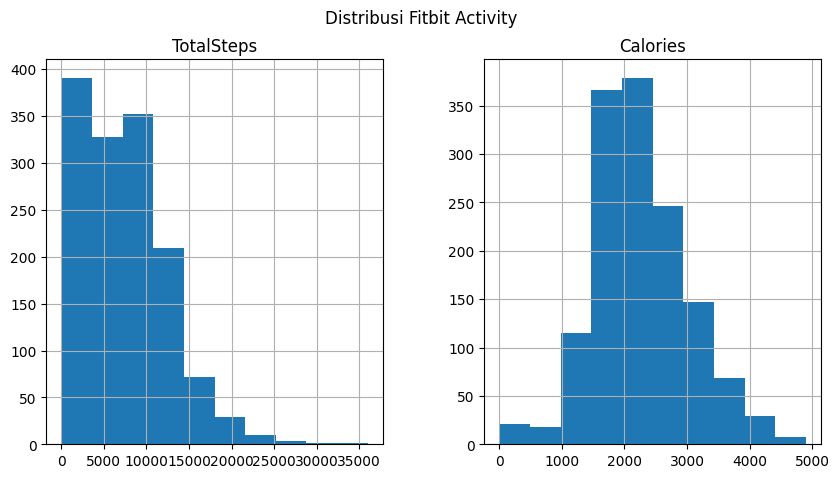

In [ ]:
df_act[['TotalSteps', 'Calories']].hist(figsize=(10,5))
plt.suptitle("Distribusi Fitbit Activity")
plt.show()

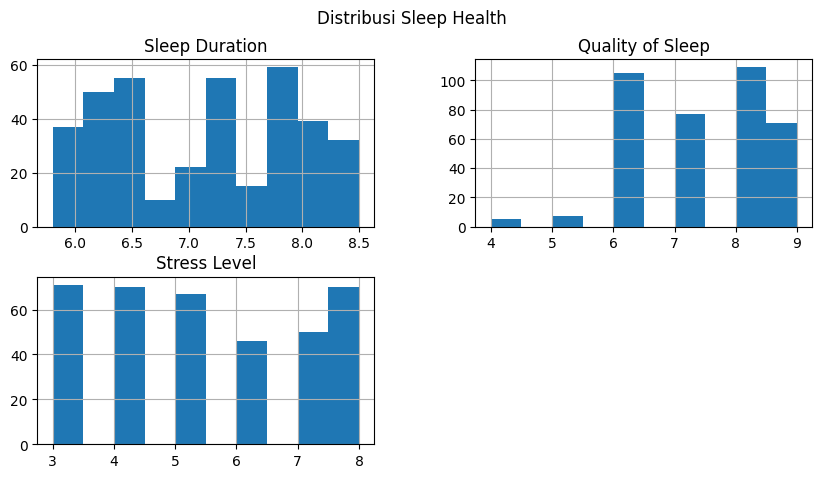

In [ ]:
df_sleep_health[['Sleep Duration', 'Quality of Sleep', 'Stress Level']].hist(figsize=(10,5))
plt.suptitle("Distribusi Sleep Health")
plt.show()

count    35.000000
mean     39.228571
std       9.490198
min       8.000000
25%      38.500000
50%      42.000000
75%      42.000000
max      62.000000
Name: ActivityDate, dtype: float64


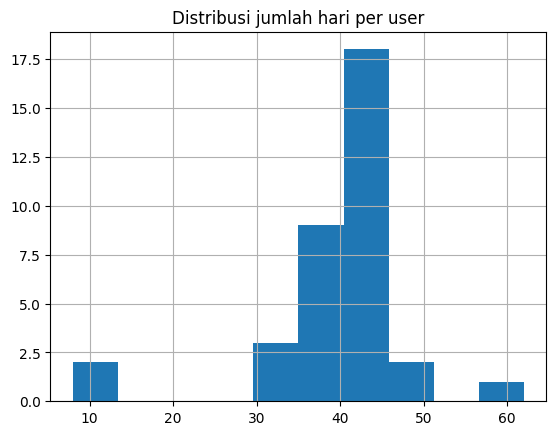

In [ ]:
#distribusi tiap user
user_days = df_act.groupby('Id')['ActivityDate'].nunique()
print(user_days.describe())
user_days.hist()
plt.title("Distribusi jumlah hari per user")
plt.show()

In [ ]:
#distribusi data kategorik
print(df_sleep_health['BMI Category'].value_counts())
print(df_sleep_health['Sleep Disorder'].value_counts())

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64
Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64


In [ ]:
#korelasi
corr = df_act[['TotalSteps', 'Calories']].corr()
print(corr)

            TotalSteps  Calories
TotalSteps     1.00000   0.59016
Calories       0.59016   1.00000


Secara keseluruhan, hasil assessing menunjukkan bahwa dataset Fitbit memiliki ukuran yang cukup besar (1397 observasi dengan 15 variabel) dan relatif bersih karena tidak ditemukan missing value maupun duplikasi pada data aktivitas, meskipun terdapat sedikit duplikasi pada data tidur (3 baris) yang perlu dibersihkan pada tahap selanjutnya. Distribusi jumlah hari per pengguna menunjukkan variasi yang cukup tinggi (mean ≈ 39 hari, std ≈ 9.49, dengan rentang 8–62 hari), yang mengindikasikan bahwa data bersifat tidak seimbang antar user ada user dengan data sangat sedikit dan ada yang sangat lengkap sehingga validasi pemilihan minimal hari (misalnya ≥14 hari) menjadi keputusan yang tepat untuk menjaga konsistensi time series. Dari sisi statistik deskriptif, variabel aktivitas seperti TotalSteps memiliki rata-rata sekitar 7.280 langkah dengan standar deviasi tinggi (~5214), menunjukkan variasi aktivitas yang besar antar individu hal ini juga didukung oleh nilai maksimum yang jauh lebih tinggi (36.019 langkah), serta skewness positif (0.68) yang menandakan distribusi condong ke kanan (banyak nilai rendah dengan sedikit nilai ekstrem tinggi). Pola ini lebih ekstrem pada variabel seperti VeryActiveMinutes dan LoggedActivitiesDistance yang memiliki skewness dan kurtosis sangat tinggi, mengindikasikan adanya outlier signifikan, yang juga terkonfirmasi melalui deteksi IQR (16 outlier pada TotalSteps dan 30 pada Calories). Variabel sedentary juga menarik karena rata-rata waktu sedentary mencapai ~992 menit per hari, yang berarti sebagian besar waktu pengguna dihabiskan dalam kondisi tidak aktif. Pada data tidur Fitbit, rata-rata durasi tidur berada di sekitar 419 menit ( ~7 jam ), dengan variasi yang cukup besar (std ~118 menit), yang masih realistis secara fisiologis, meskipun terdapat nilai minimum yang sangat rendah (58 menit) yang kemungkinan merupakan noise atau anomali. Sementara itu, dataset Sleep Health memiliki struktur yang lebih bersih tanpa duplikasi, namun terdapat missing value yang signifikan pada variabel Sleep Disorder (219 data kosong), yang mengindikasikan bahwa sebagian besar individu tidak teridentifikasi memiliki gangguan tidur (atau tidak dilaporkan), sehingga perlu penanganan khusus (misalnya imputasi menjadi “None”). Distribusi variabel dalam dataset ini relatif stabil dan mendekati normal, dengan rata-rata durasi tidur 7.13 jam, kualitas tidur 7.31 (skala 1–10), dan tingkat stres 5.38, serta standar deviasi yang moderat, menunjukkan data cukup representatif untuk generasi sintetis berbasis distribusi. Dari sisi kategori, mayoritas individu berada pada kategori BMI Normal dan Overweight, sementara Sleep Disorder didominasi oleh Sleep Apnea dan Insomnia dengan proporsi hampir seimbang. Terakhir, analisis korelasi menunjukkan adanya hubungan moderat antara TotalSteps dan Calories (≈0.59), yang secara logis konsisten bahwa semakin tinggi aktivitas fisik maka semakin tinggi kalori yang terbakar. Secara keseluruhan, data ini memiliki kualitas yang baik untuk analisis lanjutan, dengan tantangan utama berupa ketidakseimbangan jumlah hari per user, keberadaan outlier, serta missing value pada variabel tertentu, yang semuanya perlu dipertimbangkan dalam tahap cleaning dan synthetic data generation agar tidak menghasilkan bias pada model.


## Cleaning Data

cleaning data fitbit

In [ ]:
#standarisasi kolom
df_act.columns = df_act.columns.str.strip()
df_sleep.columns = df_sleep.columns.str.strip()

In [ ]:
#samakan nama dan kolom tanggal
df_sleep.rename(columns={'SleepDay': 'ActivityDate'}, inplace=True)

In [ ]:
#mengubah datetime
df_act['ActivityDate'] = pd.to_datetime(df_act['ActivityDate'])
df_sleep['ActivityDate'] = pd.to_datetime(df_sleep['ActivityDate'])


/tmp/ipykernel_3418/2430149652.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sleep['ActivityDate'] = pd.to_datetime(df_sleep['ActivityDate'])


In [ ]:
#hapus duplicate
df_sleep = df_sleep.drop_duplicates()
df_act = df_act.drop_duplicates()

In [ ]:
#merge data
df_fitbit = pd.merge(
    df_act,
    df_sleep,
    on=['Id', 'ActivityDate'],
    how='inner'
)

In [ ]:
#pastikan 1 user 1 hari 1 baris
df_fitbit = df_fitbit.groupby(['Id', 'ActivityDate']).mean(numeric_only=True).reset_index()


In [ ]:
#feature selection awal (memilih variable penting saja dan membuang variabel yang tidak penting)
cols_keep = [
    'Id',
    'ActivityDate',
    'TotalSteps',
    'Calories',
    'VeryActiveMinutes',
    'SedentaryMinutes',
    'TotalMinutesAsleep',
    'TotalTimeInBed'
]

df_fitbit = df_fitbit[cols_keep]

In [ ]:
#filtering user yang hanya memiliki 14 hari atau standarisasi
user_days = df_fitbit.groupby('Id')['ActivityDate'].nunique()

valid_users = user_days[user_days >= 14].index

df_fitbit = df_fitbit[df_fitbit['Id'].isin(valid_users)]

In [ ]:
df_fitbit = df_fitbit.sort_values(['Id', 'ActivityDate'])
df_fitbit = df_fitbit.groupby('Id').head(14)

In [ ]:
print("Jumlah user:", df_fitbit['Id'].nunique())
print("Jumlah data:", len(df_fitbit))
df_fitbit.head()

Jumlah user: 15
Jumlah data: 210


,Id,ActivityDate,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,6693.0,1017.5,12.5,380.0,327.0,346.0
1,1503960366,2016-04-13,10735.0,1797.0,21.0,776.0,384.0,407.0
2,1503960366,2016-04-15,9762.0,1745.0,29.0,726.0,412.0,442.0
3,1503960366,2016-04-16,12669.0,1863.0,36.0,773.0,340.0,367.0
4,1503960366,2016-04-17,9705.0,1728.0,38.0,539.0,700.0,712.0


In [ ]:
df_fitbit.describe()

,Id,ActivityDate,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes,TotalMinutesAsleep,TotalTimeInBed
count,2.100000e+02,210,210.00000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,5.078574e+09,2016-04-20 04:34:17.142857216,8475.02381,2378.521429,25.642857,701.914286,429.533333,466.580952
min,1.503960e+09,2016-04-12 00:00:00,655.00000,816.000000,0.000000,380.000000,59.000000,65.000000
25%,3.977334e+09,2016-04-16 00:00:00,5176.00000,1832.500000,0.000000,623.000000,377.000000,409.250000
50%,4.702922e+09,2016-04-20 00:00:00,8982.00000,2194.000000,9.000000,714.250000,433.000000,467.500000
75%,6.962181e+09,2016-04-24 00:00:00,11190.00000,2879.250000,35.000000,775.750000,492.750000,526.000000
max,8.792010e+09,2016-05-05 00:00:00,20031.00000,4900.000000,210.000000,1265.000000,700.000000,725.000000
std,2.105418e+09,NaN,4102.43643,779.962444,38.269206,139.632291,100.987807,100.593766


In [ ]:
df_fitbit.isnull().sum()

,0
Id,0
ActivityDate,0
TotalSteps,0
Calories,0
VeryActiveMinutes,0
SedentaryMinutes,0
TotalMinutesAsleep,0
TotalTimeInBed,0


In [ ]:
df_fitbit.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
Id,210.0,5.078574e+09,2.105418e+09,1.503960e+09,3.977334e+09,4.702922e+09,6.962181e+09,8.792010e+09
TotalSteps,210.0,8.475024e+03,4.102436e+03,6.550000e+02,5.176000e+03,8.982000e+03,1.119000e+04,2.003100e+04
Calories,210.0,2.378521e+03,7.799624e+02,8.160000e+02,1.832500e+03,2.194000e+03,2.879250e+03,4.900000e+03
VeryActiveMinutes,210.0,2.564286e+01,3.826921e+01,0.000000e+00,0.000000e+00,9.000000e+00,3.500000e+01,2.100000e+02
SedentaryMinutes,210.0,7.019143e+02,1.396323e+02,3.800000e+02,6.230000e+02,7.142500e+02,7.757500e+02,1.265000e+03
TotalMinutesAsleep,210.0,4.295333e+02,1.009878e+02,5.900000e+01,3.770000e+02,4.330000e+02,4.927500e+02,7.000000e+02
TotalTimeInBed,210.0,4.665810e+02,1.005938e+02,6.500000e+01,4.092500e+02,4.675000e+02,5.260000e+02,7.250000e+02


cleaning data sleep health


In [ ]:
#handle missing value
df_sleep_health['Sleep Disorder'] = df_sleep_health['Sleep Disorder'].fillna('None')


In [ ]:
#merapikan kategori data
df_sleep_health['BMI Category'] = df_sleep_health['BMI Category'].replace({
    'Normal Weight': 'Normal'
})

In [ ]:
#rename kolom agar konsisten
df_sleep_health.rename(columns={
    'Sleep Duration': 'sleep_duration',
    'Quality of Sleep': 'sleep_quality',
    'Stress Level': 'stress_level',
    'Physical Activity Level': 'physical_activity',
    'BMI Category': 'BMI_category',
    'Sleep Disorder': 'sleep_disorder'
}, inplace=True)

In [ ]:
print("Jumlah user (sleep health):", df_sleep_health['Person ID'].nunique())
print("Jumlah data:", len(df_sleep_health))

df_sleep_health.head()

Jumlah user (sleep health): 374
Jumlah data: 374


,Person ID,Gender,Age,Occupation,sleep_duration,sleep_quality,physical_activity,stress_level,BMI_category,Blood Pressure,Heart Rate,Daily Steps,sleep_disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
df_sleep_health.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
sleep_duration,0
sleep_quality,0
physical_activity,0
stress_level,0
BMI_category,0
Blood Pressure,0


In [ ]:
df_sleep_health.describe()

,Person ID,Age,sleep_duration,sleep_quality,physical_activity,stress_level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


Setelah dilakukan proses pembersihan data, dataset Fitbit berhasil dipersiapkan menjadi data time series yang konsisten dengan total 210 observasi yang berasal dari 15 pengguna, di mana setiap pengguna memiliki 14 hari data yang telah distandarisasi. Seluruh missing value pada dataset Fitbit tidak ditemukan sejak awal, sehingga proses cleaning lebih difokuskan pada penghapusan duplikasi, penyatuan data aktivitas dan tidur menggunakan metode inner join, serta agregasi untuk memastikan satu baris merepresentasikan satu pengguna dalam satu hari. Selain itu, dilakukan seleksi fitur untuk mempertahankan variabel yang relevan terhadap analisis kualitas tidur dan produktivitas, seperti TotalSteps, Calories, VeryActiveMinutes, SedentaryMinutes, serta variabel tidur seperti TotalMinutesAsleep dan TotalTimeInBed. Sementara itu, pada dataset Sleep Health, ditemukan missing value yang cukup signifikan pada variabel Sleep Disorder, yang kemudian ditangani dengan mengisi nilai kosong menjadi kategori “None” untuk merepresentasikan tidak adanya gangguan tidur. Proses cleaning juga mencakup standarisasi kategori pada variabel BMI serta penghapusan kolom yang tidak relevan seperti Blood Pressure dan Occupation guna mengurangi noise dalam data. Setelah proses ini, kedua dataset berada dalam kondisi bersih, konsisten, dan siap untuk tahap selanjutnya, yaitu eksplorasi lebih lanjut dan proses generasi data sintetis tanpa risiko bias akibat kualitas data yang buruk.

# SYNTHETIC DATA GENERATION

Tahap ini dilakukan untuk membentuk dataset simulasi yang memiliki struktur observasi harian. Dataset Sleep Health and Lifestyle bersifat *cross-sectional*, sedangkan data Fitbit memiliki dimensi harian. Oleh karena itu, dilakukan proses perluasan data menggunakan pendekatan bootstrap sampling dan penambahan noise terbatas agar variabel kesehatan tidur dapat disesuaikan dengan struktur harian.

Perlu ditekankan bahwa proses ini bukan untuk menciptakan data klinis baru, tetapi untuk membangun dataset awal yang cukup representatif sebagai *proof of concept* pengembangan sistem SleepWell AI. Dengan pendekatan ini, tim dapat menguji alur Data Science, pemodelan AI, API, dan dashboard sebelum tersedia data longitudinal nyata dari pengguna aplikasi.


Dalam proses pengembangan dataset, dilakukan penambahan data sintetis untuk meningkatkan jumlah sampel dan mengurangi risiko bias akibat keterbatasan jumlah pengguna. Pada dataset Fitbit, distribusi variabel menunjukkan adanya skewness dan outlier yang signifikan, sehingga tidak memenuhi asumsi distribusi normal. Oleh karena itu, digunakan pendekatan bootstrap sampling dengan penambahan noise kecil untuk menghasilkan data sintetis yang tetap mempertahankan pola distribusi asli. Sementara itu, pada dataset Sleep Health, variabel numerik menunjukkan distribusi yang relatif stabil dan mendekati normal, sehingga proses generasi data sintetis dilakukan menggunakan distribusi normal berdasarkan nilai mean dan standar deviasi. Pendekatan ini memungkinkan terciptanya data tambahan yang realistis tanpa merusak karakteristik statistik dari dataset asli.

Bootstrap sampling merupakan teknik pengambilan sampel ulang dari data asli dengan metode pengembalian (with replacement), sehingga memungkinkan terbentuknya data baru yang tetap mempertahankan distribusi asli. Dalam penelitian ini, metode bootstrap digunakan untuk menghasilkan data sintetis yang realistis, terutama pada variabel yang tidak berdistribusi normal, dengan tujuan menjaga karakteristik data agar tidak mengalami distorsi.

Pada dataset Fitbit, digunakan metode bootstrap sampling dengan pengembalian (with replacement) karena data memiliki distribusi yang tidak normal dan mengandung banyak outlier, sehingga diperlukan pendekatan yang dapat mempertahankan pola distribusi asli. Sementara itu, pada dataset Sleep Health, data sintetis dihasilkan menggunakan distribusi normal berdasarkan nilai rata-rata dan standar deviasi, sehingga tidak menggunakan teknik sampling dengan atau tanpa pengembalian, melainkan membangkitkan data baru secara langsung dari distribusi statistik.

In [ ]:
import numpy as np
import pandas as pd

DATA FITBIT (data tidak normal maka dilakukan
pengambilan sampel dengan pengembalian agar datanya cukup 30 user)

In [ ]:
#parameter data
n_new_users = 15
days_per_user = 14

real_users = df_fitbit['Id'].unique()
new_user_ids = np.arange(max(real_users)+1, max(real_users)+1+n_new_users)

In [ ]:
features = [
    'TotalSteps',
    'Calories',
    'VeryActiveMinutes',
    'SedentaryMinutes',
    'TotalMinutesAsleep',
    'TotalTimeInBed'
]

synthetic_rows = []

for user in new_user_ids:
    base_date = pd.to_datetime("2016-04-12")

    for i in range(days_per_user):
        row = {'Id': user}
        row['ActivityDate'] = base_date + pd.Timedelta(days=i)

        for col in features:
            # bootstrap sampling
            base_val = np.random.choice(df_fitbit[col])

            # noise kecil (10% dari std)
            noise = np.random.normal(0, df_fitbit[col].std() * 0.1)

            val = base_val + noise

            # jaga nilai tidak negatif
            val = max(val, 0)

            row[col] = val

        synthetic_rows.append(row)

df_synth_fitbit = pd.DataFrame(synthetic_rows)

In [ ]:
#gabungkan data
df_fitbit_final = pd.concat([df_fitbit, df_synth_fitbit], ignore_index=True)

In [ ]:
print("Fitbit synthetic user:", df_synth_fitbit['Id'].nunique())
print("Fitbit synthetic data:", len(df_synth_fitbit))

Fitbit synthetic user: 15
Fitbit synthetic data: 210


In [ ]:
print("Fitbit user:", df_fitbit['Id'].nunique())
print("Fitbit data:", len(df_fitbit))

Fitbit user: 15
Fitbit data: 210


In [ ]:
print("Total user:", df_fitbit_final['Id'].nunique())
print("Total data:", len(df_fitbit_final))

df_fitbit_final.describe()

Total user: 30
Total data: 420


,Id,ActivityDate,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes,TotalMinutesAsleep,TotalTimeInBed
count,4.200000e+02,420,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000
mean,6.935292e+09,2016-04-19 08:17:08.571428608,8350.419879,2382.384775,25.425006,702.501944,432.254100,466.589376
min,1.503960e+09,2016-04-12 00:00:00,655.000000,816.000000,0.000000,374.795734,59.000000,65.000000
25%,4.702922e+09,2016-04-15 00:00:00,4857.230185,1819.229200,0.000000,623.000000,379.493345,408.834399
50%,8.792010e+09,2016-04-19 00:00:00,8939.500000,2206.746468,8.000000,717.637823,438.468444,463.944762
75%,8.792010e+09,2016-04-23 00:00:00,11123.782971,2881.359779,35.291343,774.524419,497.043525,522.000000
max,8.792010e+09,2016-05-05 00:00:00,20455.895803,4900.000000,210.000000,1265.000000,711.483164,725.000000
std,2.380490e+09,NaN,4146.396861,783.168700,37.929321,136.426476,100.143629,98.564541


Data time series dalam penelitian ini (fitbit) tidak dipaksakan untuk berdistribusi normal, karena sebagian besar model machine learning yang digunakan tidak mensyaratkan normalitas data. Fokus utama adalah menjaga pola temporal dan hubungan antar variabel. Untuk mengatasi keterbatasan jumlah user, digunakan pendekatan penambahan data sintetis, di mana 15 user asli dipertahankan sebagai anchor, dan ditambahkan 15 user sintetis menggunakan metode bootstrap sampling dengan pengembalian serta penambahan noise kecil. Pendekatan ini dipilih untuk menjaga distribusi data tetap realistis dan menghindari distorsi yang dapat terjadi jika menggunakan distribusi normal secara langsung pada data yang tidak normal.

SLEEP HEALTH (normal distribusi) karena normal maka akan dilakukan random sampling

Untuk menjaga konsistensi antar dataset, dilakukan proses sampling pada data Sleep Health dengan mengambil 30 individu secara acak tanpa pengembalian, sehingga jumlah user sesuai dengan dataset Fitbit. Hal ini bertujuan agar proses integrasi data dapat dilakukan secara seimbang dan menghindari bias akibat perbedaan jumlah observasi antar dataset.

In [ ]:
#random sampling 30 user
np.random.seed(42)

selected_users = np.random.choice(
    df_sleep_health['Person ID'].unique(),
    size=30,
    replace=False
)

df_sleep_sample = df_sleep_health[
    df_sleep_health['Person ID'].isin(selected_users)
]

In [ ]:
#parameter
days_per_user = 14

df_sleep_expanded = df_sleep_sample.loc[
    df_sleep_sample.index.repeat(days_per_user)
].copy().reset_index(drop=True)

In [ ]:
df_sleep_expanded['day'] = df_sleep_expanded.groupby('Person ID').cumcount() + 1

In [ ]:
#noise
df_sleep_expanded['sleep_duration'] += np.random.normal(0, 0.2, len(df_sleep_expanded))
df_sleep_expanded['stress_level'] += np.random.normal(0, 0.5, len(df_sleep_expanded))
df_sleep_expanded['physical_activity'] += np.random.normal(0, 5, len(df_sleep_expanded))

In [ ]:
print("Total user:", df_sleep_expanded['Person ID'].nunique())
print("Total data:", len(df_sleep_expanded))

Total user: 30
Total data: 420


Data Sleep Health awalnya hanya tersedia dalam bentuk satu observasi per individu. Untuk menyesuaikan dengan data Fitbit yang bersifat time series, dilakukan proses ekspansi data dengan mengulang setiap individu menjadi beberapa observasi harian. Nilai asli digunakan sebagai baseline, kemudian ditambahkan variasi kecil (noise) untuk mensimulasikan perubahan kondisi harian secara realistis tanpa mengubah karakteristik utama setiap individu.

Dalam proses pengembangan dataset, dilakukan penambahan data sintetis untuk meningkatkan jumlah sampel dan mengurangi risiko bias akibat keterbatasan jumlah pengguna. Pada dataset Fitbit, distribusi variabel menunjukkan adanya skewness dan outlier yang signifikan, sehingga tidak memenuhi asumsi distribusi normal. Oleh karena itu, digunakan pendekatan bootstrap sampling dengan penambahan noise kecil untuk menghasilkan data sintetis yang tetap mempertahankan pola distribusi asli. Sementara itu, pada dataset Sleep Health, variabel numerik menunjukkan distribusi yang relatif stabil dan mendekati normal, sehingga proses generasi data sintetis dilakukan menggunakan distribusi normal berdasarkan nilai mean dan standar deviasi. Pendekatan ini memungkinkan terciptanya data tambahan yang realistis tanpa merusak karakteristik statistik dari dataset asli.

Proses sintesis data dilakukan untuk mengatasi keterbatasan jumlah pengguna pada dataset Fitbit yang awalnya hanya berjumlah 15 user, sehingga berpotensi menimbulkan bias dan rendahnya kemampuan generalisasi model. Oleh karena itu, jumlah user ditingkatkan menjadi 30 dengan menambahkan data sintetis berbasis distribusi data asli (bootstrap + noise) agar pola aktivitas tetap realistis dan tidak terdistorsi. Sementara itu, pada dataset Sleep Health yang awalnya berjumlah 374 individu dengan struktur cross-sectional, dilakukan proses sampling tanpa pengembalian untuk mengambil 30 user agar konsisten dengan jumlah user pada Fitbit, sehingga integrasi data menjadi seimbang dan tidak berat sebelah. Selanjutnya, data Sleep Health diubah menjadi time series dengan mengulang setiap individu menjadi 14 hari dan menambahkan variasi kecil (noise) untuk mensimulasikan dinamika harian tanpa menghilangkan karakteristik utama tiap individu. Pendekatan ini dipilih karena penggunaan seluruh data Sleep Health akan menyebabkan ketidakseimbangan jumlah observasi dan berpotensi menimbulkan bias pada model, sedangkan penggunaan sampling menjaga representativitas distribusi data. Secara keseluruhan, strategi ini menghasilkan dataset akhir yang lebih stabil, konsisten secara struktur, serta siap digunakan untuk pemodelan tanpa melanggar prinsip data wrangling, di mana data tidak hanya digunakan apa adanya tetapi telah melalui proses penyesuaian yang terkontrol dan berbasis distribusi asli.

In [ ]:
# pastikan urut dulu
df_fitbit_final = df_fitbit_final.sort_values(['Id', 'ActivityDate'])

# buat index hari (1–14 per user)
df_fitbit_final['day'] = df_fitbit_final.groupby('Id').cumcount() + 1

In [ ]:
#samakan nama kolom sleep dan fitbit
df_sleep_expanded = df_sleep_expanded.rename(columns={
    'Person ID': 'Id'
})

In [ ]:
#cek kolom untu memastikan
df_sleep_expanded = df_sleep_expanded[[
    'Id',
    'day',
    'sleep_duration',
    'sleep_quality',
    'stress_level',
    'physical_activity',
    'BMI_category',
    'sleep_disorder'
]]

In [ ]:
print("Fitbit user:", df_fitbit_final['Id'].nunique())
print("Sleep user:", df_sleep_expanded['Id'].nunique())

print("Fitbit data:", len(df_fitbit_final))
print("Sleep data:", len(df_sleep_expanded))

Fitbit user: 30
Sleep user: 30
Fitbit data: 420
Sleep data: 420


Sebelum proses penggabungan data, dilakukan penyesuaian struktur antara dataset Fitbit dan Sleep Health, di mana kedua dataset diselaraskan dalam bentuk time series dengan jumlah hari yang sama per individu. Selain itu, dilakukan penyamaan variabel kunci berupa ID pengguna dan indeks waktu (day) agar proses merging dapat dilakukan secara akurat dan menghasilkan dataset yang terintegrasi dengan baik.

Dilakukan proses penyesuaian ID antar dataset dengan melakukan mapping ID pada data Sleep Health agar sesuai dengan ID pada dataset Fitbit. Hal ini bertujuan untuk memastikan bahwa setiap observasi mewakili individu yang sama, sehingga proses integrasi data dapat dilakukan secara akurat.

In [ ]:
fitbit_ids = sorted(df_fitbit_final['Id'].unique())

In [ ]:
sleep_ids = sorted(df_sleep_expanded['Id'].unique())

id_mapping = dict(zip(sleep_ids, fitbit_ids))

df_sleep_expanded['Id'] = df_sleep_expanded['Id'].map(id_mapping)

In [ ]:
print(set(df_fitbit_final['Id']) == set(df_sleep_expanded['Id']))

True


In [ ]:
df_final = pd.merge(
    df_fitbit_final,
    df_sleep_expanded,
    on=['Id', 'day'],
    how='inner'
)

In [ ]:
print("Final data:", len(df_final))

Final data: 420


In [ ]:
df_final.head()

,Id,ActivityDate,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes,TotalMinutesAsleep,TotalTimeInBed,day,sleep_duration,sleep_quality,stress_level,physical_activity,BMI_category,sleep_disorder
0,1503960366,2016-04-12,6693.0,1017.5,12.5,380.0,327.0,346.0,1,5.863347,6,6.698582,48.584718,Overweight,None
1,1503960366,2016-04-13,10735.0,1797.0,21.0,776.0,384.0,407.0,2,6.198999,6,5.654800,44.196514,Overweight,None
2,1503960366,2016-04-15,9762.0,1745.0,29.0,726.0,412.0,442.0,3,6.066938,6,6.308108,37.558946,Overweight,None
3,1503960366,2016-04-16,12669.0,1863.0,36.0,773.0,340.0,367.0,4,5.962565,6,5.684794,35.184802,Overweight,None
4,1503960366,2016-04-17,9705.0,1728.0,38.0,539.0,700.0,712.0,5,6.113670,6,5.542379,38.637553,Overweight,None


In [ ]:
df_final.sample(5)

,Id,ActivityDate,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes,TotalMinutesAsleep,TotalTimeInBed,day,sleep_duration,sleep_quality,stress_level,physical_activity,BMI_category,sleep_disorder
90,4445114986,2016-04-19,2064.000000,1954.00000,0.000000,895.000000,388.000000,424.00000,7,5.926447,6,7.990055,34.012354,Normal,None
381,8792009678,2016-04-15,20455.895803,1341.66507,50.489575,719.276299,479.345069,561.50077,4,8.544155,9,2.897373,25.597690,Normal,None
140,6117666160,2016-04-16,14450.000000,2828.00000,7.000000,502.000000,380.000000,398.00000,1,7.518032,8,4.141779,60.288978,Normal,None
331,8792009674,2016-04-21,6886.950655,3702.49861,37.453999,631.371388,439.073555,422.24750,10,6.163026,7,3.406679,42.531147,Overweight,Insomnia
17,2026352035,2016-04-15,3821.000000,1444.00000,0.000000,687.000000,523.000000,573.00000,4,7.903739,7,6.138591,74.302473,Normal,None


In [ ]:
print("Shape:", df_final.shape)

Shape: (420, 15)


In [ ]:
df_final['Id'].nunique()

30

In [ ]:
df_final.groupby('Id')['day'].nunique()

,day
Id,
1503960366,14
2026352035,14
2347167796,14
3977333714,14
4319703577,14
4388161847,14
4445114986,14
4702921684,14
5553957443,14


In [ ]:
df_final.isnull().sum()

,0
Id,0
ActivityDate,0
TotalSteps,0
Calories,0
VeryActiveMinutes,0
SedentaryMinutes,0
TotalMinutesAsleep,0
TotalTimeInBed,0
day,0
sleep_duration,0


In [ ]:
df_final.duplicated().sum()

np.int64(0)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  420 non-null    int64         
 1   ActivityDate        420 non-null    datetime64[ns]
 2   TotalSteps          420 non-null    float64       
 3   Calories            420 non-null    float64       
 4   VeryActiveMinutes   420 non-null    float64       
 5   SedentaryMinutes    420 non-null    float64       
 6   TotalMinutesAsleep  420 non-null    float64       
 7   TotalTimeInBed      420 non-null    float64       
 8   day                 420 non-null    int64         
 9   sleep_duration      420 non-null    float64       
 10  sleep_quality       420 non-null    int64         
 11  stress_level        420 non-null    float64       
 12  physical_activity   420 non-null    float64       
 13  BMI_category        420 non-null    object        

Hasil penggabungan data menunjukkan bahwa dataset akhir telah memiliki struktur yang konsisten dengan 30 pengguna dan 14 observasi per pengguna, tanpa adanya missing value maupun duplikasi data. Hal ini menandakan bahwa proses integrasi data berhasil dilakukan dengan baik dan dataset telah siap digunakan untuk analisis lanjutan.

## Interpretasi Akhir Synthetic Data Generation

Data sintetis pada dataset SleepWell AI dihasilkan menggunakan pendekatan bootstrap sampling yang dikombinasikan dengan penambahan noise terbatas. Tujuannya adalah mempertahankan pola distribusi asli dari dataset Sleep Health and Lifestyle sambil menyesuaikannya dengan struktur observasi harian pada data Fitbit.

Hasil sintesis ini digunakan sebagai dataset simulasi untuk kebutuhan capstone project. Oleh karena itu, seluruh hasil analisis harus dibaca sebagai temuan eksploratif dan *proof of concept*, bukan sebagai kesimpulan klinis. Dataset ini cukup memadai untuk menguji alur kerja awal, mulai dari data wrangling, EDA, feature engineering, model prediksi, hingga integrasi aplikasi.


In [ ]:
df_final['sleep_duration'] = df_final['sleep_duration'].round(2)
df_final['sleep_quality'] = df_final['sleep_quality'].round(0)
df_final['stress_level'] = df_final['stress_level'].round(2)
df_final['physical_activity'] = df_final['physical_activity'].round(2)

In [ ]:
df_final.to_csv('df_final.csv', index=False)

# Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami pola hubungan antara aktivitas harian, tidur, stres, dan indikator kesehatan yang tersedia dalam dataset. Fokus utama analisis ini adalah mengidentifikasi variabel yang berkaitan dengan `fitness_score` dan `wellbeing_index`, bukan membuktikan hubungan sebab-akibat.

Pada tahap ini, kata "berkaitan", "berhubungan", atau "memiliki korelasi" digunakan secara hati-hati karena EDA tidak dapat membuktikan kausalitas. Hasil EDA digunakan sebagai dasar untuk memilih fitur, menyusun insight, dan mendukung sistem rekomendasi sederhana pada aplikasi.


Data aktivitas Fitbit yang digunakan memiliki periode waktu April 2016, sedangkan dataset Sleep Health and Lifestyle tidak memiliki dimensi waktu dan digunakan sebagai representasi karakteristik kesehatan individu dalam analisis.

**Pertanyaan Utama EDA**

Bagaimana pola hubungan antara aktivitas fisik, durasi tidur, kualitas tidur, tingkat stres, waktu tidak aktif, BMI, dan gangguan tidur terhadap pembentukan `fitness_score` serta `wellbeing_index` pada dataset SleepWell AI?

Pertanyaan ini membantu tim melihat fitur mana yang layak dipertahankan dalam dataset final dan bagaimana insight tersebut dapat diterjemahkan menjadi rekomendasi untuk pengguna aplikasi.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

green = "#2E7D32"
light_green = "#A5D6A7"
medium_green = "#66BB6A"
dark_green = "#1B5E20"

palette_green = ["#C8E6C9", "#A5D6A7", "#66BB6A", "#43A047", "#2E7D32", "#1B5E20"]

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [ ]:
print("Jumlah baris dan kolom:", df_final.shape)

print("\nInformasi dataset:")
display(df_final.info())

print("\nJumlah missing value pada setiap kolom:")
display(df_final.isnull().sum())

print("\nStatistik deskriptif:")
display(df_final.describe())

Jumlah baris dan kolom: (420, 15)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  420 non-null    int64         
 1   ActivityDate        420 non-null    datetime64[ns]
 2   TotalSteps          420 non-null    float64       
 3   Calories            420 non-null    float64       
 4   VeryActiveMinutes   420 non-null    float64       
 5   SedentaryMinutes    420 non-null    float64       
 6   TotalMinutesAsleep  420 non-null    float64       
 7   TotalTimeInBed      420 non-null    float64       
 8   day                 420 non-null    int64         
 9   sleep_duration      420 non-null    float64       
 10  sleep_quality       420 non-null    int64         
 11  stress_level        420 non-null    float64       
 12  physical_activity   420 non-null    float64       
 

None


Jumlah missing value pada setiap kolom:


,0
Id,0
ActivityDate,0
TotalSteps,0
Calories,0
VeryActiveMinutes,0
SedentaryMinutes,0
TotalMinutesAsleep,0
TotalTimeInBed,0
day,0
sleep_duration,0



Statistik deskriptif:


,Id,ActivityDate,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes,TotalMinutesAsleep,TotalTimeInBed,day,sleep_duration,sleep_quality,stress_level,physical_activity
count,4.200000e+02,420,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000
mean,6.935292e+09,2016-04-19 08:17:08.571428608,8350.419879,2382.384775,25.425006,702.501944,432.254100,466.589376,7.500000,6.941976,7.100000,5.773500,48.523452
min,1.503960e+09,2016-04-12 00:00:00,655.000000,816.000000,0.000000,374.795734,59.000000,65.000000,1.000000,5.630000,6.000000,1.990000,17.840000
25%,4.702922e+09,2016-04-15 00:00:00,4857.230185,1819.229200,0.000000,623.000000,379.493345,408.834399,4.000000,6.200000,6.000000,4.077500,32.555000
50%,8.792010e+09,2016-04-19 00:00:00,8939.500000,2206.746468,8.000000,717.637823,438.468444,463.944762,7.500000,6.765000,7.000000,5.830000,45.275000
75%,8.792010e+09,2016-04-23 00:00:00,11123.782971,2881.359779,35.291343,774.524419,497.043525,522.000000,11.000000,7.650000,8.000000,7.330000,61.292500
max,8.792010e+09,2016-05-05 00:00:00,20455.895803,4900.000000,210.000000,1265.000000,711.483164,725.000000,14.000000,9.030000,9.000000,9.380000,101.090000
std,2.380490e+09,NaN,4146.396861,783.168700,37.929321,136.426476,100.143629,98.564541,4.035936,0.869772,1.166149,1.827886,18.839641


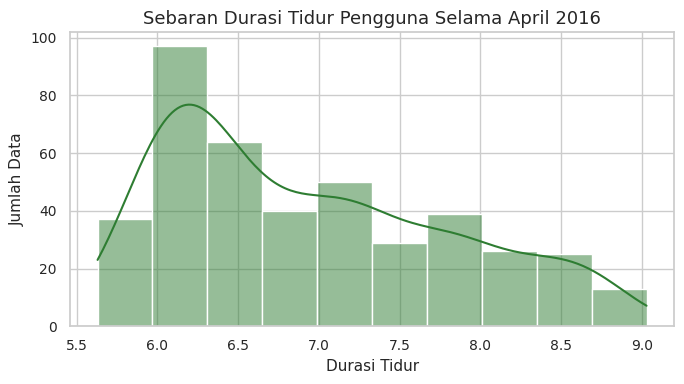

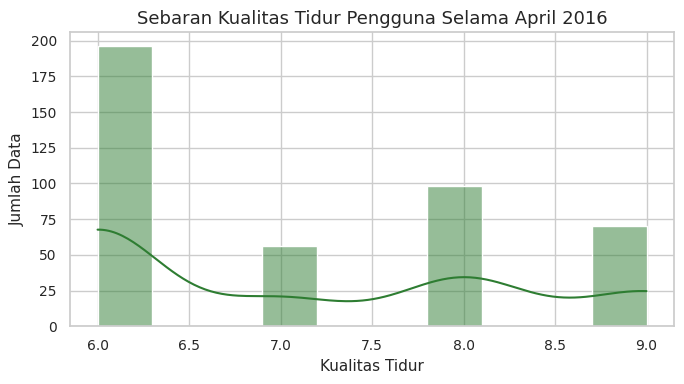

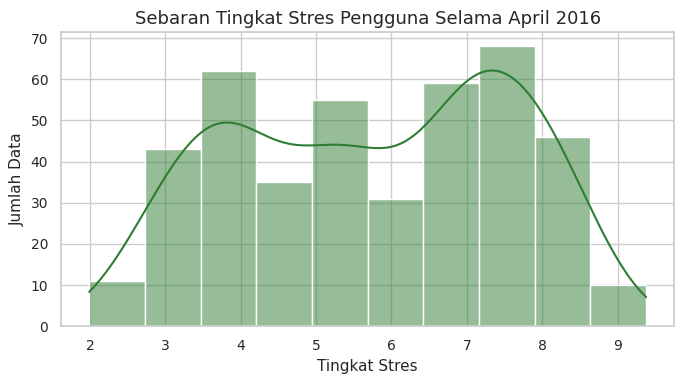

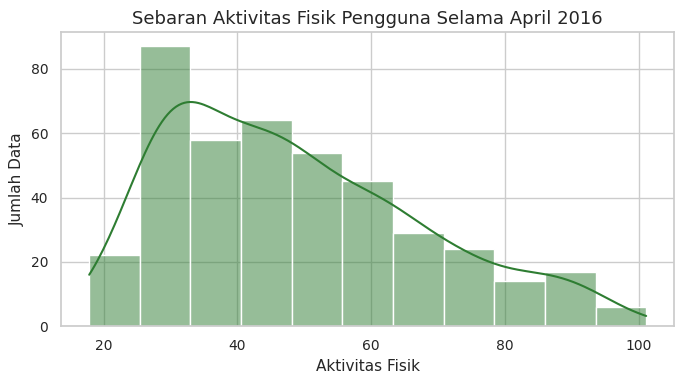

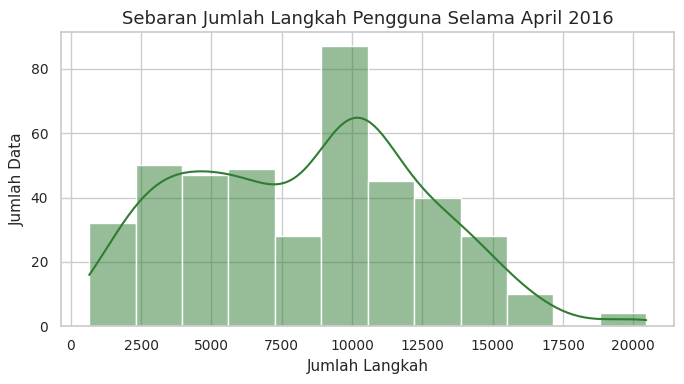

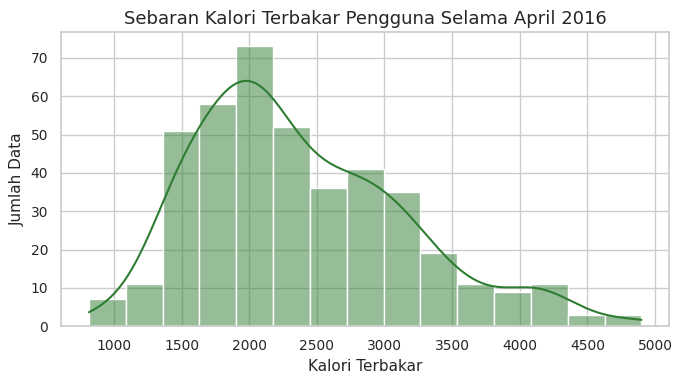

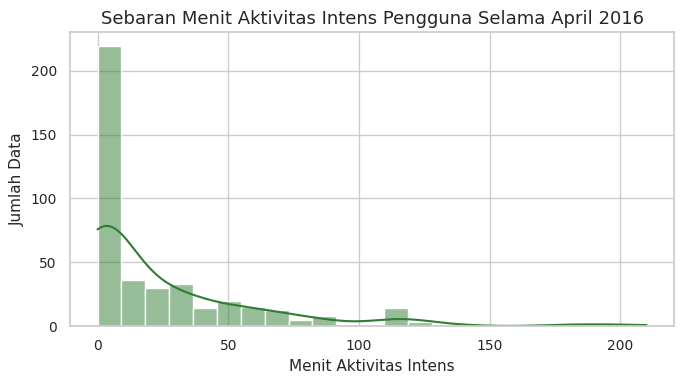

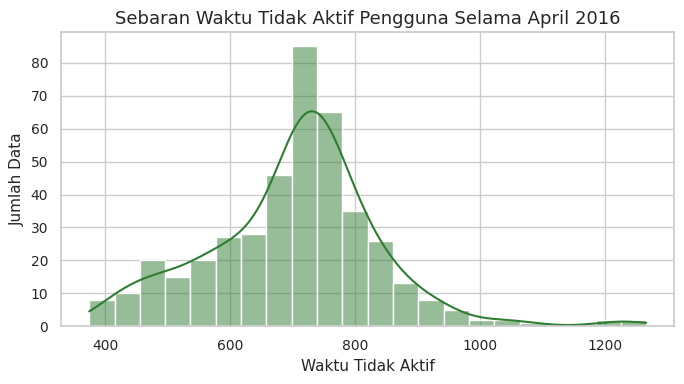

In [ ]:
# distribusi statistik (kurva normal)
num_cols = [
    "sleep_duration",
    "sleep_quality",
    "stress_level",
    "physical_activity",
    "TotalSteps",
    "Calories",
    "VeryActiveMinutes",
    "SedentaryMinutes"
]

label_indonesia = {
    "sleep_duration": "Durasi Tidur",
    "sleep_quality": "Kualitas Tidur",
    "stress_level": "Tingkat Stres",
    "physical_activity": "Aktivitas Fisik",
    "TotalSteps": "Jumlah Langkah",
    "Calories": "Kalori Terbakar",
    "VeryActiveMinutes": "Menit Aktivitas Intens",
    "SedentaryMinutes": "Waktu Tidak Aktif"
}

judul_distribusi = {
    "sleep_duration": "Sebaran Durasi Tidur Pengguna Selama April 2016",
    "sleep_quality": "Sebaran Kualitas Tidur Pengguna Selama April 2016",
    "stress_level": "Sebaran Tingkat Stres Pengguna Selama April 2016",
    "physical_activity": "Sebaran Aktivitas Fisik Pengguna Selama April 2016",
    "TotalSteps": "Sebaran Jumlah Langkah Pengguna Selama April 2016",
    "Calories": "Sebaran Kalori Terbakar Pengguna Selama April 2016",
    "VeryActiveMinutes": "Sebaran Menit Aktivitas Intens Pengguna Selama April 2016",
    "SedentaryMinutes": "Sebaran Waktu Tidak Aktif Pengguna Selama April 2016"
}

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df_final, x=col, kde=True, color=green)
    plt.title(judul_distribusi[col])
    plt.xlabel(label_indonesia[col])
    plt.ylabel("Jumlah Data")
    plt.tight_layout()
    plt.show()

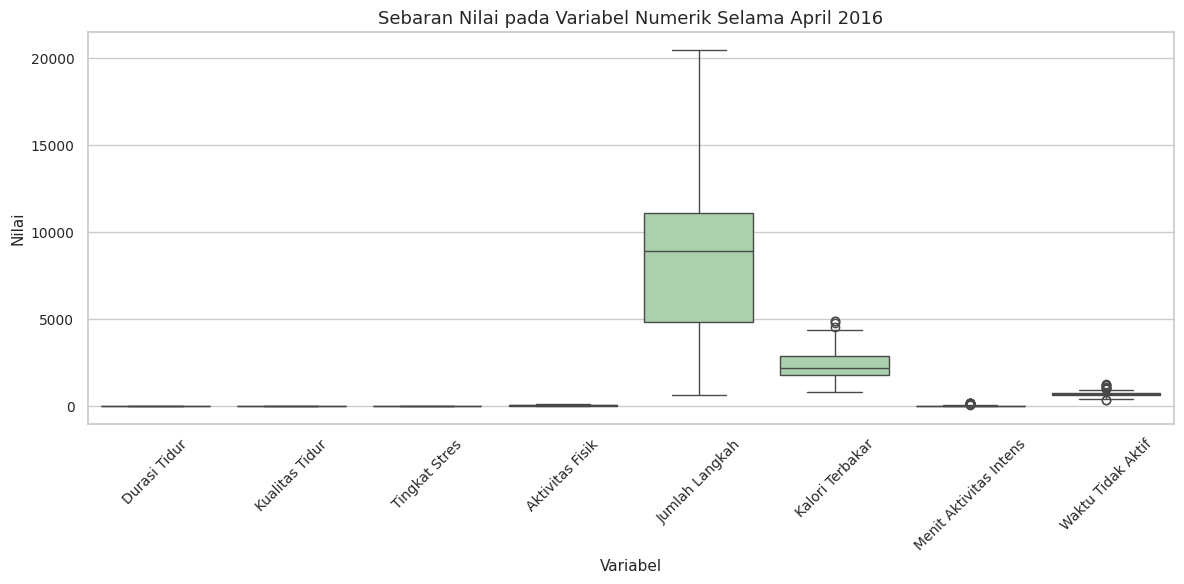

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_final[num_cols], color=light_green)

plt.title("Sebaran Nilai pada Variabel Numerik Selama April 2016")
plt.xlabel("Variabel")
plt.ylabel("Nilai")
plt.xticks(
    ticks=range(len(num_cols)),
    labels=[label_indonesia[col] for col in num_cols],
    rotation=45
)
plt.tight_layout()
plt.show()

In [ ]:
df_final[['TotalSteps','sleep_duration','Calories']].describe()

,TotalSteps,sleep_duration,Calories
count,420.000000,420.000000,420.000000
mean,8350.419879,6.941976,2382.384775
std,4146.396861,0.869772,783.168700
min,655.000000,5.630000,816.000000
25%,4857.230185,6.200000,1819.229200
50%,8939.500000,6.765000,2206.746468
75%,11123.782971,7.650000,2881.359779
max,20455.895803,9.030000,4900.000000


Ditemukan adanya beberapa nilai ekstrem (outlier) pada variabel seperti TotalSteps, sleep_duration, dan Calories. Namun, nilai-nilai tersebut tidak dihapus karena masih berada dalam rentang yang logis dan realistis secara kontekstual.

Sebagai contoh, nilai maksimum TotalSteps sebesar 20.031 langkah masih mencerminkan tingkat aktivitas fisik yang tinggi namun memungkinkan terjadi pada individu tertentu. Demikian pula, rentang sleep_duration antara 5,63 hingga 9,03 jam masih sesuai dengan variasi pola tidur manusia pada kondisi normal. Nilai Calories yang mencapai 4.900 juga dapat terjadi pada individu dengan aktivitas fisik intens.

Selain itu, proses sintesis data menggunakan pendekatan bootstrap sampling dengan penambahan noise bertujuan untuk mempertahankan distribusi asli data, sehingga keberadaan nilai ekstrem merupakan bagian dari variasi alami data, bukan kesalahan. Oleh karena itu, outlier tidak dihapus agar informasi penting mengenai variasi perilaku pengguna tetap terjaga dan analisis yang dilakukan tetap merepresentasikan kondisi yang lebih realistis.

### Pertanyaan 1: Aktivitas Fisik dan Kualitas Tidur

Bagaimana hubungan antara jumlah langkah harian (`TotalSteps`) dan menit aktivitas intens (`VeryActiveMinutes`) dengan kualitas tidur (`sleep_quality`) pengguna selama april 2016?


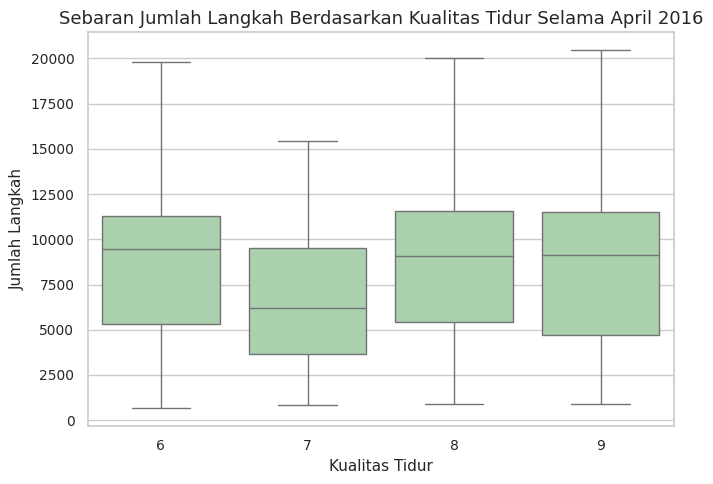

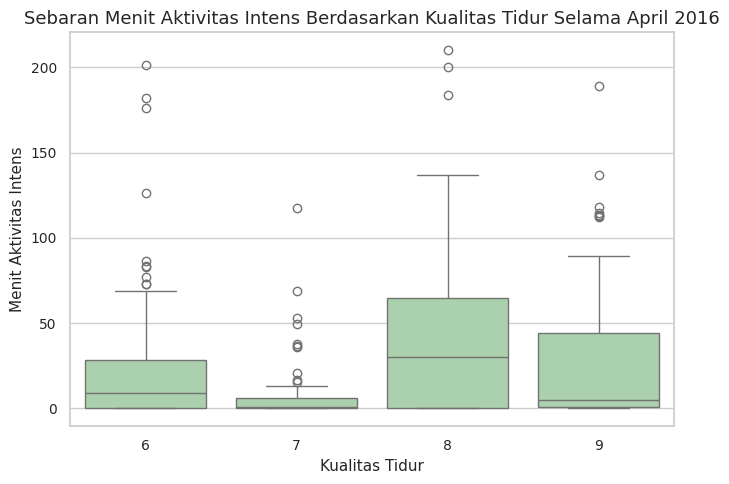

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_final,
    x="sleep_quality",
    y="TotalSteps",
    color=light_green
)

plt.title("Sebaran Jumlah Langkah Berdasarkan Kualitas Tidur Selama April 2016")
plt.xlabel("Kualitas Tidur")
plt.ylabel("Jumlah Langkah")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_final,
    x="sleep_quality",
    y="VeryActiveMinutes",
    color=light_green
)

plt.title("Sebaran Menit Aktivitas Intens Berdasarkan Kualitas Tidur Selama April 2016")
plt.xlabel("Kualitas Tidur")
plt.ylabel("Menit Aktivitas Intens")
plt.tight_layout()
plt.show()

**Interpretasi:**

Pada visualisasi pertama, terlihat bahwa jumlah langkah pengguna memiliki sebaran yang berbeda pada setiap tingkat kualitas tidur. Pengguna dengan kualitas tidur 6 dan 8 memiliki median jumlah langkah yang relatif lebih tinggi dibandingkan kualitas tidur 7 dan 9. Kelompok kualitas tidur 8 juga memiliki rentang jumlah langkah yang cukup luas, bahkan mencapai sekitar 20.000 langkah, sehingga menunjukkan adanya variasi aktivitas fisik yang besar pada kelompok tersebut. Namun, pola peningkatannya belum terlihat konsisten, karena kualitas tidur yang lebih tinggi tidak selalu diikuti oleh jumlah langkah yang lebih tinggi.

Pada visualisasi kedua, menit aktivitas intens juga menunjukkan variasi pada setiap tingkat kualitas tidur. Kelompok kualitas tidur 8 memiliki sebaran aktivitas intens yang paling lebar, sedangkan kualitas tidur 7 cenderung memiliki aktivitas intens yang lebih rendah dan lebih rapat. Beberapa outlier muncul pada kualitas tidur 6, 8, dan 9, yang menunjukkan adanya pengguna dengan aktivitas intens jauh lebih tinggi dibandingkan mayoritas data. Secara keseluruhan, aktivitas fisik tampak memiliki hubungan dengan kualitas tidur, tetapi hubungannya tidak bersifat linear sederhana sehingga perlu dianalisis lebih lanjut dengan korelasi atau pemodelan statistik.

### Pertanyaan 2: Aktivitas dan Durasi Tidur

Apakah jumlah langkah harian (`TotalSteps`) memiliki hubungan dengan durasi tidur (`sleep_duration`) pengguna selama april 2016?


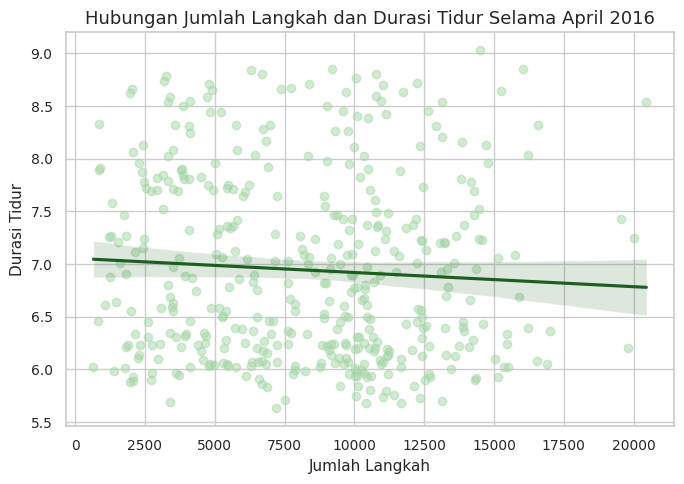

In [ ]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=df_final,
    x="TotalSteps",
    y="sleep_duration",
    scatter_kws={"alpha": 0.5, "color": light_green},
    line_kws={"color": dark_green}
)

plt.title("Hubungan Jumlah Langkah dan Durasi Tidur Selama April 2016")
plt.xlabel("Jumlah Langkah")
plt.ylabel("Durasi Tidur")
plt.tight_layout()
plt.show()

**Interpretasi:**

Visualisasi ini menunjukkan hubungan antara jumlah langkah harian dan durasi tidur pengguna selama April 2016. Titik-titik data tersebar cukup acak, sehingga tidak terlihat pola hubungan yang kuat antara semakin banyak langkah dengan semakin lama durasi tidur. Garis tren terlihat sedikit menurun, yang mengindikasikan adanya kecenderungan negatif yang sangat lemah dimana pengguna dengan jumlah langkah lebih tinggi tidak selalu memiliki durasi tidur yang lebih panjang.

Hasil ini menunjukkan bahwa jumlah langkah harian saja belum cukup kuat untuk menjelaskan durasi tidur pengguna. Durasi tidur kemungkinan dipengaruhi oleh faktor lain seperti tingkat stres, waktu tidak aktif, kebiasaan tidur, pekerjaan, atau kondisi kesehatan. Jadi, variabel jumlah langkah tetap bisa dipertimbangkan dalam analisis, tetapi sebaiknya tidak dijadikan satu-satunya indikator utama untuk memprediksi durasi tidur.


### Pertanyaan 3: Stres dan Pola Tidur

Bagaimana hubungan tingkat stres (`stress_level`) dengan durasi tidur (`sleep_duration`) dan kualitas tidur (`sleep_quality`) pengguna selama april 2016?


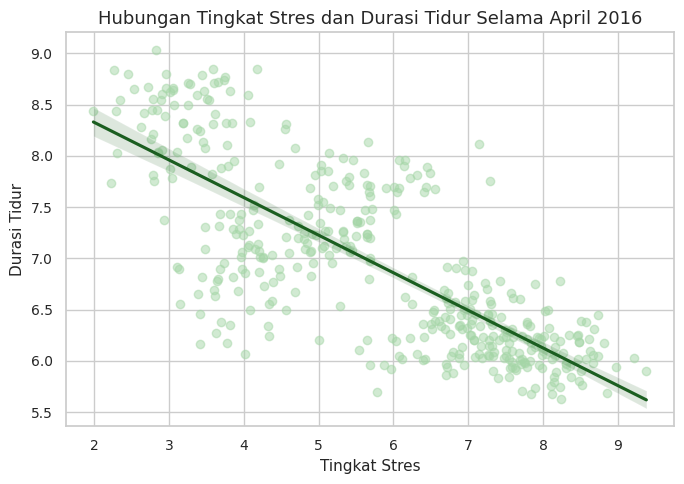

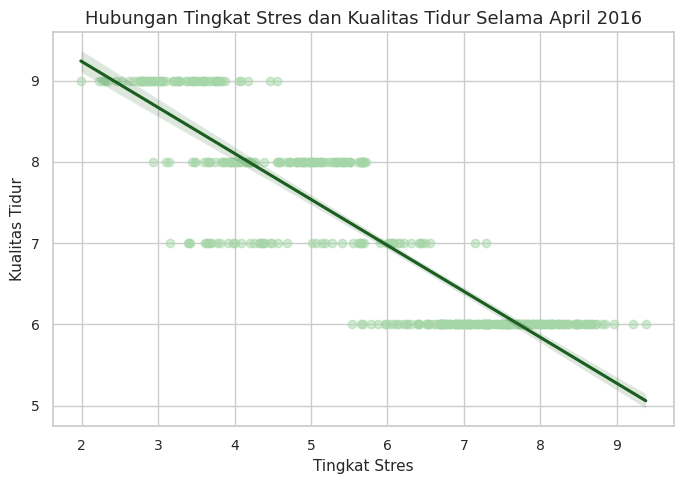

In [ ]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=df_final,
    x="stress_level",
    y="sleep_duration",
    scatter_kws={"alpha": 0.5, "color": light_green},
    line_kws={"color": dark_green}
)

plt.title("Hubungan Tingkat Stres dan Durasi Tidur Selama April 2016")
plt.xlabel("Tingkat Stres")
plt.ylabel("Durasi Tidur")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
sns.regplot(
    data=df_final,
    x="stress_level",
    y="sleep_quality",
    scatter_kws={"alpha": 0.5, "color": light_green},
    line_kws={"color": dark_green}
)

plt.title("Hubungan Tingkat Stres dan Kualitas Tidur Selama April 2016")
plt.xlabel("Tingkat Stres")
plt.ylabel("Kualitas Tidur")
plt.tight_layout()
plt.show()

**Interpretasi:**

Pada visualisasi pertama, terlihat hubungan negatif yang cukup jelas antara tingkat stres dan durasi tidur selama April 2016. Semakin tinggi tingkat stres pengguna, durasi tidurnya cenderung semakin menurun. Pengguna dengan tingkat stres rendah berada pada durasi tidur yang lebih panjang, sekitar 7,5 hingga 9 jam, sedangkan pengguna dengan tingkat stres tinggi lebih banyak berada pada durasi tidur sekitar 5,7 hingga 6,5 jam. Garis tren yang menurun tajam memperkuat bahwa stres merupakan salah satu faktor yang cukup berpengaruh terhadap berkurangnya durasi tidur.

Pada visualisasi kedua, hubungan antara tingkat stres dan kualitas tidur juga menunjukkan pola negatif yang kuat. Pengguna dengan tingkat stres rendah cenderung memiliki kualitas tidur tinggi, terutama pada skor 8 sampai 9. Sebaliknya, ketika tingkat stres meningkat, kualitas tidur cenderung turun hingga berada pada skor 5 sampai 6. Secara keseluruhan, kedua visualisasi ini menunjukkan bahwa stres memiliki hubungan yang konsisten dengan pola tidur, dimana semakin tinggi tingkat stres maka semakin pendek durasi tidur dan semakin rendah kualitas tidur pengguna.


### Pertanyaan 4: Waktu Tidak Aktif dan Kualitas Tidur

Apakah waktu tidak aktif (`SedentaryMinutes`) memiliki hubungan negatif dengan kualitas tidur pengguna selama april 2016?


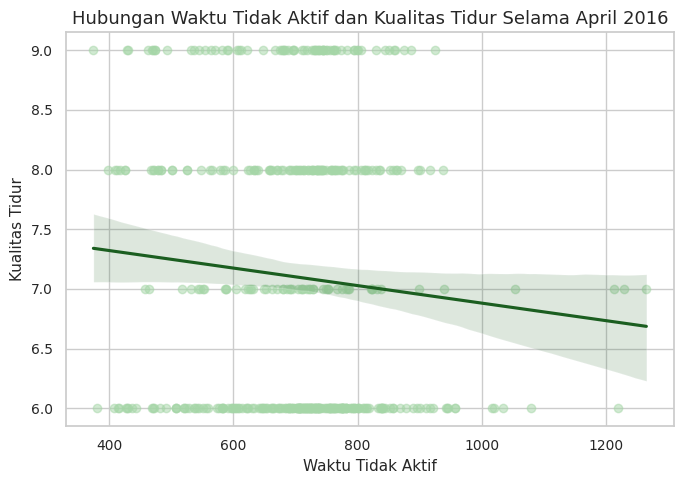

In [ ]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=df_final,
    x="SedentaryMinutes",
    y="sleep_quality",
    scatter_kws={"alpha": 0.5, "color": light_green},
    line_kws={"color": dark_green}
)

plt.title("Hubungan Waktu Tidak Aktif dan Kualitas Tidur Selama April 2016")
plt.xlabel("Waktu Tidak Aktif")
plt.ylabel("Kualitas Tidur")
plt.tight_layout()
plt.show()

**Interpretasi:**

Visualisasi ini menunjukkan hubungan antara waktu tidak aktif dan kualitas tidur pengguna selama April 2016. Garis tren terlihat sedikit menurun, yang berarti semakin lama waktu tidak aktif pengguna maka kualitas tidurnya cenderung sedikit lebih rendah. Namun, titik data masih tersebar cukup lebar pada beberapa tingkat kualitas tidur, terutama pada skor 6, 7, 8, dan 9 sehingga hubungan antara waktu tidak aktif dan kualitas tidur tidak terlihat sangat kuat.

Waktu tidak aktif kemungkinan memiliki pengaruh terhadap kualitas tidur tetapi pengaruhnya tidak sebesar variabel lain seperti tingkat stres. Pola ini menunjukkan bahwa pengguna dengan waktu tidak aktif yang tinggi cenderung memiliki kualitas tidur lebih rendah tetapi masih ada faktor lain yang juga berperan, seperti aktivitas fisik, stres, kebiasaan tidur, atau kondisi kesehatan. Jadi, variabel waktu tidak aktif tetap relevan untuk analisis tetapi sebaiknya digunakan bersama variabel lain agar hasilnya lebih akurat.


### Pertanyaan 5: BMI dan Gangguan Tidur

Bagaimana pola kategori BMI (`BMI_category`) terhadap kategori gangguan tidur (`sleep_disorder`) pengguna selama april 2016 dalam dataset yang dianalisis?


/tmp/ipykernel_3418/877052138.py:2: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


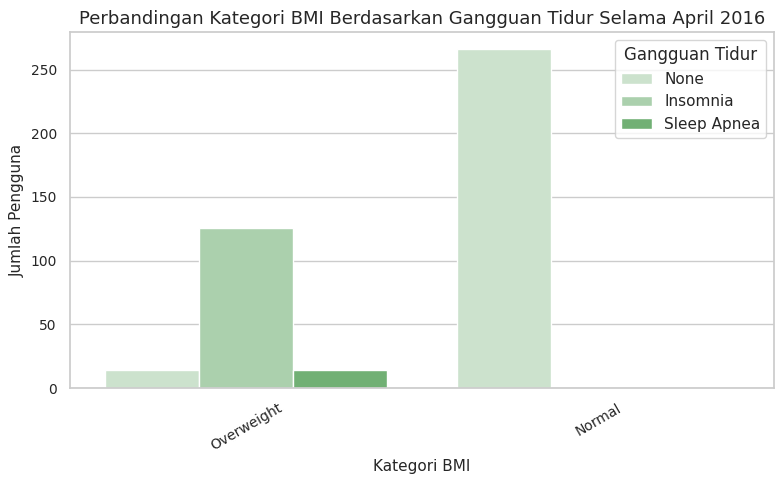

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_final,
    x="BMI_category",
    hue="sleep_disorder",
    palette=palette_green
)

plt.title("Perbandingan Kategori BMI Berdasarkan Gangguan Tidur Selama April 2016")
plt.xlabel("Kategori BMI")
plt.ylabel("Jumlah Pengguna")
plt.legend(title="Gangguan Tidur")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretasi:**

Visualisasi ini menunjukkan bahwa kategori BMI memiliki perbedaan pola terhadap gangguan tidur selama April 2016. Pada kategori **Normal**, mayoritas pengguna berada pada kelompok **None** artinya sebagian besar pengguna dengan BMI normal tidak mengalami gangguan tidur. Sementara itu, pada kategori **Overweight**, jumlah pengguna dengan **Insomnia** terlihat paling dominan dibandingkan kategori gangguan tidur lainnya. Ada juga sebagian kecil pengguna overweight yang masuk ke kelompok **None** dan **Sleep Apnea** tetapi jumlahnya jauh lebih sedikit dibandingkan insomnia.

Pola ini mengindikasikan bahwa pengguna dengan BMI normal cenderung lebih banyak tidak mengalami gangguan tidur sedangkan pengguna dengan BMI overweight lebih banyak berkaitan dengan gangguan tidur terutama insomnia. Namun, perlu diperhatikan bahwa distribusi datanya tidak sepenuhnya seimbang karena jumlah pada tiap kategori BMI dan gangguan tidur berbeda cukup besar. Jadi, BMI terlihat sebagai variabel yang relevan untuk analisis gangguan tidur tetapi interpretasinya tetap perlu hati-hati dan sebaiknya dikombinasikan dengan variabel lain seperti tingkat stres, aktivitas fisik, serta durasi tidur.


### Pertanyaan 6: Aktivitas dan Gangguan Tidur

Apakah terdapat perbedaan pola aktivitas fisik (`physical_activity`) pada setiap kategori gangguan tidur (`sleep_disorder`) pengguna selama april 2016?


/tmp/ipykernel_3418/3987939748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3418/3987939748.py:2: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.boxplot(


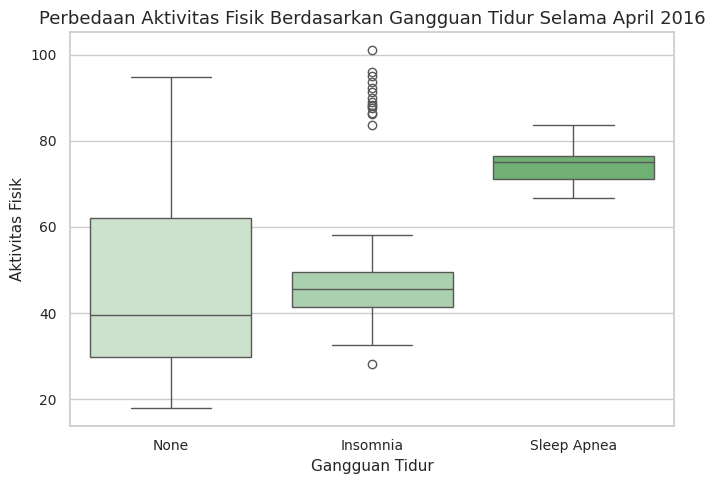

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_final,
    x="sleep_disorder",
    y="physical_activity",
    palette=palette_green
)

plt.title("Perbedaan Aktivitas Fisik Berdasarkan Gangguan Tidur Selama April 2016")
plt.xlabel("Gangguan Tidur")
plt.ylabel("Aktivitas Fisik")
plt.tight_layout()
plt.show()

**Interpretasi:**

Visualisasi ini menunjukkan bahwa tingkat aktivitas fisik berbeda pada setiap kelompok gangguan tidur selama April 2016. Kelompok **None** memiliki sebaran aktivitas fisik yang paling lebar, mulai dari rendah hingga cukup tinggi, yang berarti pengguna tanpa gangguan tidur memiliki variasi aktivitas yang beragam. Kelompok Insomnia menunjukkan tingkat aktivitas fisik yang umumnya berada pada kategori sedang, tetapi terdapat beberapa outlier dengan aktivitas fisik sangat tinggi. Hal ini tidak dapat langsung diartikan bahwa aktivitas fisik tinggi menyebabkan insomnia. Namun, aktivitas yang sangat intens, terutama jika dilakukan terlalu dekat dengan waktu tidur dapat membuat tubuh lebih sulit rileks sehingga berpotensi mengganggu proses tidur pada sebagian pengguna. Oleh karena itu, aktivitas fisik tetap menjadi variabel yang relevan untuk dianalisis tetapi perlu dilihat bersama faktor lain seperti waktu aktivitas, tingkat stres, durasi tidur, BMI, dan kebiasaan tidur. Sementara itu, kelompok **Sleep Apnea** memiliki median aktivitas fisik paling tinggi dan sebarannya relatif lebih rapat.

SHasil ini menunjukkan bahwa aktivitas fisik memiliki perbedaan pola pada setiap kategori gangguan tidur, tetapi hubungannya tidak bisa langsung disimpulkan sebagai sebab-akibat. Misalnya, kelompok **Sleep Apnea** terlihat memiliki aktivitas fisik lebih tinggi, tetapi jumlah atau karakteristik datanya perlu diperiksa lagi sebelum menyimpulkan bahwa aktivitas fisik berkaitan langsung dengan sleep apnea. Variabel ini tetap relevan untuk analisis lanjutan, tetapi perlu dikombinasikan dengan faktor lain seperti BMI, tingkat stres, durasi tidur, dan kualitas tidur.


### Pertanyaan 7: Konsistensi Pola Tidur

Bagaimana variasi harian durasi tidur (`sleep_duration`) pada setiap pengguna selama april 2016, dan apakah terdapat pola tidur yang relatif konsisten atau berfluktuasi?


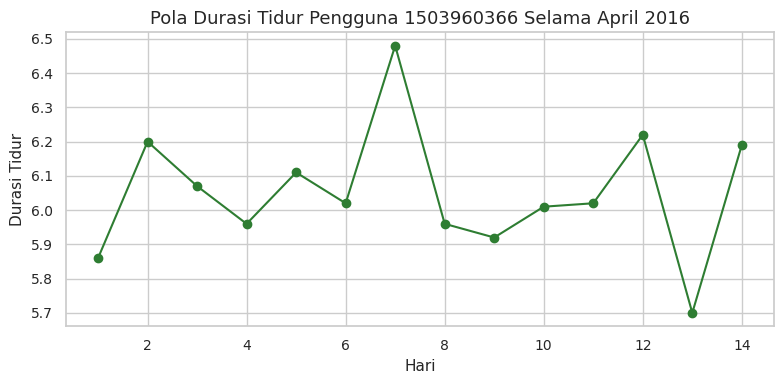

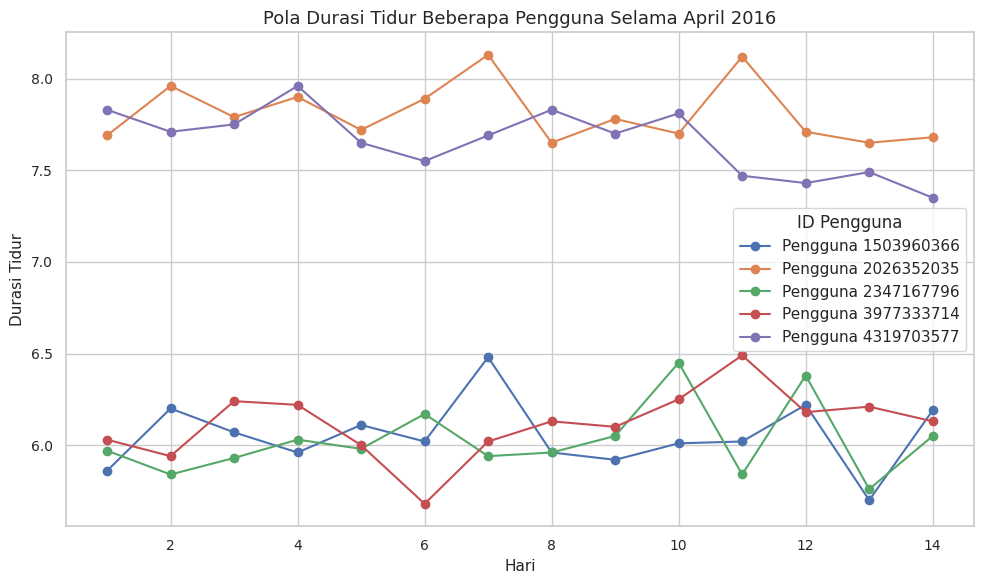

In [ ]:
sample_user = df_final["Id"].iloc[0]
df_sample = df_final[df_final["Id"] == sample_user]

plt.figure(figsize=(8, 4))
plt.plot(
    df_sample["day"],
    df_sample["sleep_duration"],
    marker="o",
    color=green
)

plt.title(f"Pola Durasi Tidur Pengguna {sample_user} Selama April 2016")
plt.xlabel("Hari")
plt.ylabel("Durasi Tidur")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

for user in df_final["Id"].unique()[:5]:
    temp = df_final[df_final["Id"] == user]
    plt.plot(
        temp["day"],
        temp["sleep_duration"],
        marker="o",
        label=f"Pengguna {user}"
    )

plt.title("Pola Durasi Tidur Beberapa Pengguna Selama April 2016")
plt.xlabel("Hari")
plt.ylabel("Durasi Tidur")
plt.legend(title="ID Pengguna")
plt.tight_layout()
plt.show()

**Interpretasi:**

Pada visualisasi pertama, pola durasi tidur pengguna **1503960366** selama April 2016 terlihat cukup stabil di sekitar 5,8 sampai 6,5 jam. Meskipun ada kenaikan pada hari ke-7 dan penurunan cukup jelas pada hari ke-13, perubahan tersebut masih berada dalam rentang yang tidak terlalu ekstrem. Artinya, pengguna ini memiliki pola tidur yang relatif konsisten tetapi durasi tidurnya cenderung berada di bawah rekomendasi umum 7–9 jam untuk orang dewasa.

Pada visualisasi beberapa pengguna, terlihat bahwa setiap pengguna memiliki pola durasi tidur yang berbeda. Ada pengguna yang konsisten tidur lebih lama, sekitar 7,5 sampai 8 jam, sementara beberapa pengguna lain cenderung berada di sekitar 6 jam. Perbedaan ini menunjukkan bahwa pola tidur sangat bervariasi antarindividu, sehingga analisis tidur tidak cukup hanya melihat rata-rata keseluruhan. Variabel berbasis individu seperti kebiasaan harian, tingkat stres, aktivitas fisik, dan kondisi kesehatan perlu dipertimbangkan karena setiap pengguna memiliki baseline tidur yang berbeda.


### Pertanyaan 8: Korelasi Antar Variabel Numerik

Seberapa kuat hubungan statistik antara variabel aktivitas harian, variabel tidur, stres, `fitness_score`, dan `wellbeing_index` pengguna selama april 2016?


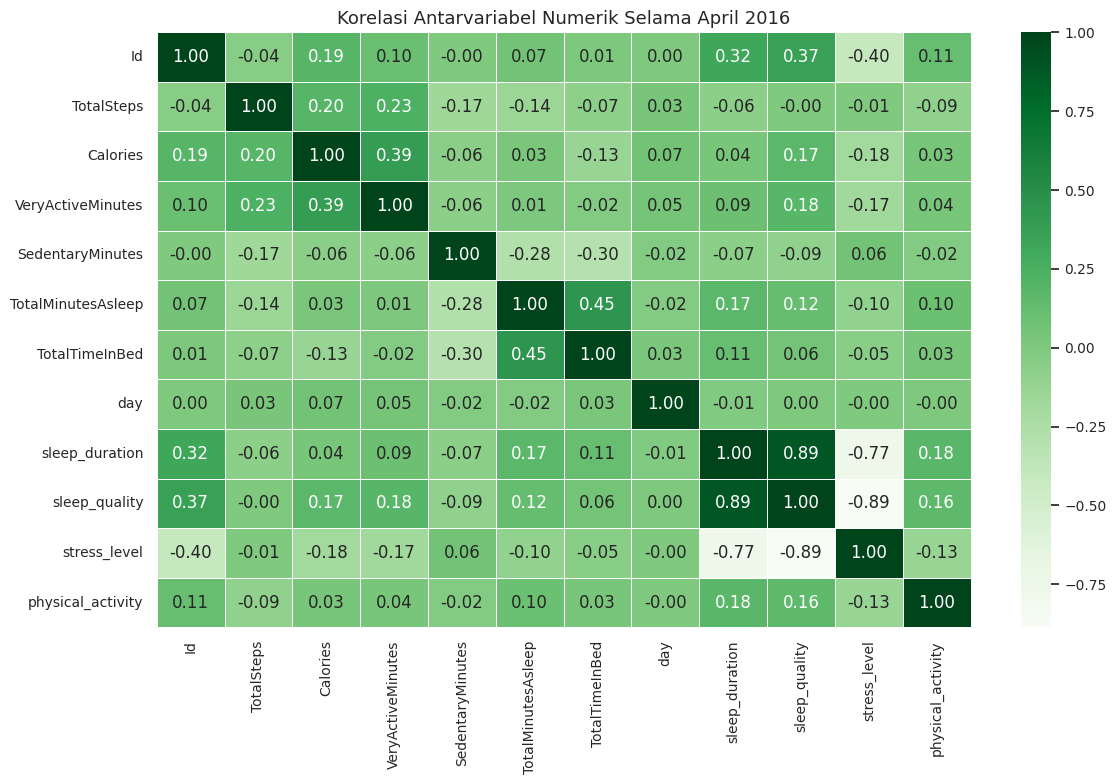

In [ ]:
plt.figure(figsize=(12, 8))

corr = df_final.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Korelasi Antarvariabel Numerik Selama April 2016")
plt.tight_layout()
plt.show()

**Interpretasi:**

Heatmap korelasi ini menunjukkan bahwa hubungan paling kuat terdapat antara **sleep_duration** dan **sleep_quality** dengan nilai korelasi **0,89**. Artinya, semakin lama durasi tidur pengguna, kualitas tidurnya cenderung semakin baik. Sebaliknya, **stress_level** memiliki korelasi negatif yang sangat kuat dengan **sleep_quality** sebesar **-0,89** dan dengan **sleep_duration** sebesar **-0,77**. Ini menunjukkan bahwa semakin tinggi tingkat stres, maka kualitas tidur dan durasi tidur pengguna cenderung menurun. Temuan ini cukup konsisten dengan visualisasi sebelumnya, di mana stres terlihat sebagai faktor yang paling kuat berkaitan dengan pola tidur.

Variabel aktivitas fisik seperti **TotalSteps**, **VeryActiveMinutes**, dan **physical_activity** memiliki korelasi yang relatif lemah terhadap kualitas tidur maupun durasi tidur. Misalnya, korelasi **physical_activity** terhadap **sleep_quality** hanya sekitar **0,16**, dan terhadap **sleep_duration** sekitar **0,18**. Ini berarti aktivitas fisik tetap relevan, tetapi pengaruhnya tidak sekuat stres dalam dataset ini. Selain itu, **SedentaryMinutes** memiliki korelasi negatif lemah terhadap durasi dan kualitas tidur, sehingga waktu tidak aktif memang cenderung berkaitan dengan tidur yang lebih buruk, tetapi hubungannya tidak dominan. Secara keseluruhan, faktor yang paling menonjol dalam analisis ini adalah **tingkat stres**, kemudian disusul oleh **durasi tidur** sebagai faktor yang sangat berkaitan dengan kualitas tidur.


### Pertanyaan 9: Faktor yang Paling Berkaitan dengan Kualitas Tidur dan Well-being

Variabel apa saja yang paling berkaitan dengan kualitas tidur dan `wellbeing_index`pengguna selama april 2016 berdasarkan hasil korelasi dan visualisasi?


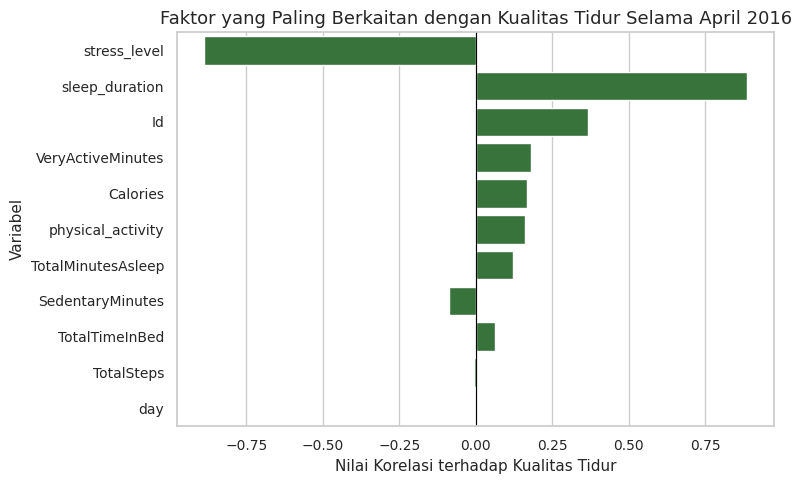

,sleep_quality
stress_level,-8.865473e-01
sleep_duration,8.860715e-01
Id,3.653921e-01
VeryActiveMinutes,1.822135e-01
Calories,1.690726e-01
physical_activity,1.597162e-01
TotalMinutesAsleep,1.214292e-01
SedentaryMinutes,-8.591212e-02
TotalTimeInBed,6.329917e-02
TotalSteps,-4.235944e-03


In [ ]:
target_corr = (
    df_final.select_dtypes(include="number")
    .corr()["sleep_quality"]
    .drop("sleep_quality")
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    color=green
)

plt.title("Faktor yang Paling Berkaitan dengan Kualitas Tidur Selama April 2016")
plt.xlabel("Nilai Korelasi terhadap Kualitas Tidur")
plt.ylabel("Variabel")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

display(target_corr)

**Interpretasi:**

Visualisasi ini menunjukkan faktor-faktor yang paling berkaitan dengan **kualitas tidur** selama April 2016. Faktor dengan hubungan paling kuat adalah **stress_level** dan **sleep_duration**. **Stress_level** memiliki korelasi negatif paling besar, sekitar **-0,89**, yang berarti semakin tinggi tingkat stres, kualitas tidur pengguna cenderung semakin menurun. Sebaliknya, **sleep_duration** memiliki korelasi positif sangat kuat, sekitar **0,89**, sehingga semakin lama durasi tidur pengguna, kualitas tidurnya cenderung semakin baik. Dua variabel ini menjadi faktor paling dominan dalam menjelaskan perubahan kualitas tidur pada dataset.

Variabel lain seperti **physical_activity**, **TotalTimeInBed**, **VeryActiveMinutes**, dan **Calories** hanya memiliki korelasi positif yang lemah terhadap kualitas tidur. Artinya, variabel-variabel tersebut tetap memiliki hubungan, tetapi pengaruhnya tidak sebesar stres dan durasi tidur. Sementara itu, **SedentaryMinutes** memiliki korelasi negatif lemah, yang menunjukkan bahwa semakin lama waktu tidak aktif, kualitas tidur cenderung sedikit menurun. Secara keseluruhan, kualitas tidur dalam data ini paling kuat berkaitan dengan **tingkat stres yang lebih rendah** dan **durasi tidur yang lebih panjang**, sedangkan aktivitas fisik berperan sebagai faktor pendukung, bukan faktor utama.


### Pertanyaan 10: Implikasi untuk Pemodelan

Apakah variabel aktivitas harian, tidur, stres, dan fitur turunan pengguna selama april 2016 sudah cukup siap digunakan untuk membangun model prediksi `fitness_score_next_day` dan `wellbeing_next_day`?


/tmp/ipykernel_3418/1835161014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_3418/1835161014.py:2: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


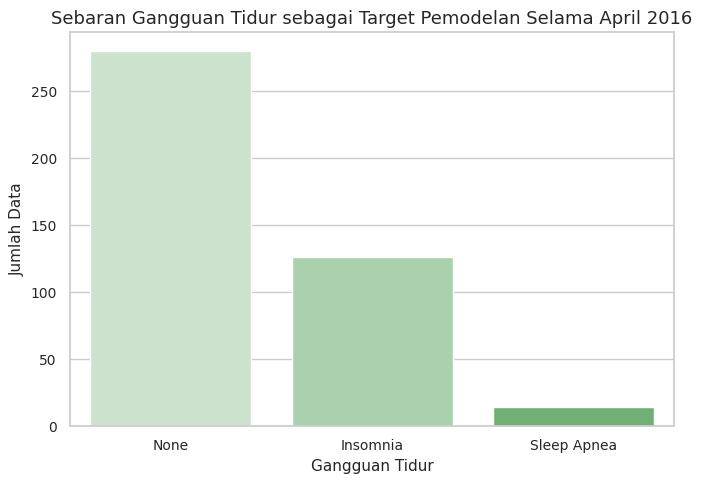

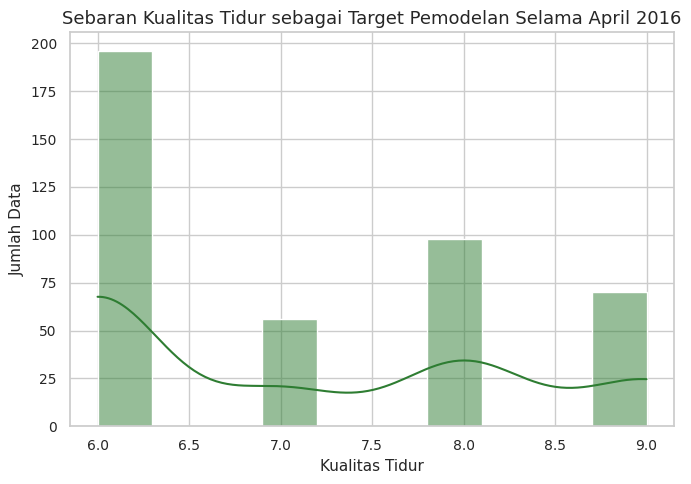

Tidak terdapat missing value pada dataset. Data cukup siap untuk tahap pemodelan awal.


In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_final,
    x="sleep_disorder",
    palette=palette_green
)

plt.title("Sebaran Gangguan Tidur sebagai Target Pemodelan Selama April 2016")
plt.xlabel("Gangguan Tidur")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
sns.histplot(
    data=df_final,
    x="sleep_quality",
    kde=True,
    color=green
)

plt.title("Sebaran Kualitas Tidur sebagai Target Pemodelan Selama April 2016")
plt.xlabel("Kualitas Tidur")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()


missing_values = df_final.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_values) > 0:
    plt.figure(figsize=(8, 5))
    sns.barplot(
        x=missing_values.values,
        y=missing_values.index,
        color=green
    )

    plt.title("Jumlah Missing Value pada Dataset Selama April 2016")
    plt.xlabel("Jumlah Missing Value")
    plt.ylabel("Kolom")
    plt.tight_layout()
    plt.show()
else:
    print("Tidak terdapat missing value pada dataset. Data cukup siap untuk tahap pemodelan awal.")

**Interpretasi:**

Visualisasi pertama menunjukkan bahwa target **gangguan tidur** memiliki distribusi yang tidak seimbang. Kategori **None** mendominasi jumlah data, disusul oleh **Insomnia**, sedangkan **Sleep Apnea** memiliki jumlah data yang jauh lebih sedikit. Dari sudut pandang pemodelan, kondisi ini perlu diperhatikan karena model berpotensi lebih mudah mengenali kelas mayoritas dan kurang optimal dalam memprediksi kelas minoritas seperti **Sleep Apnea**. Jika target ini digunakan untuk klasifikasi, evaluasi model sebaiknya tidak hanya menggunakan akurasi, tetapi juga metrik seperti precision, recall, F1-score, dan confusion matrix.

Visualisasi kedua menunjukkan bahwa target **kualitas tidur** tersebar pada beberapa nilai utama, yaitu sekitar 6, 7, 8, dan 9, dengan jumlah data paling banyak berada pada kualitas tidur 6. Ini menunjukkan bahwa distribusi kualitas tidur belum sepenuhnya merata, tetapi masih cukup informatif untuk dianalisis. Selain itu, hasil pengecekan menunjukkan tidak terdapat missing value, sehingga dataset sudah cukup siap untuk tahap pemodelan awal. Namun, sebelum modeling, data tetap perlu melalui proses encoding untuk variabel kategorikal, scaling bila diperlukan, serta pemisahan data latih dan data uji agar hasil model lebih valid.


## Final Interpretasi EDA

Berdasarkan hasil EDA, tingkat stres menjadi salah satu variabel yang paling kuat berkaitan dengan kualitas tidur, durasi tidur, dan `wellbeing_index`. Pengguna dengan tingkat stres lebih tinggi cenderung memiliki durasi tidur dan kualitas tidur yang lebih rendah. Pola ini relevan untuk sistem rekomendasi karena stres dapat menjadi salah satu indikator utama ketika aplikasi memberikan saran perbaikan kebiasaan tidur.

Aktivitas fisik seperti jumlah langkah, menit aktivitas intens, dan kalori juga memberikan informasi penting untuk membentuk `fitness_score`. Namun, hubungan aktivitas dengan kualitas tidur tidak selalu linear. Artinya, aktivitas yang lebih tinggi tidak otomatis selalu diikuti kualitas tidur yang lebih tinggi. Oleh karena itu, fitur aktivitas perlu digunakan bersama variabel lain seperti stres, durasi tidur, dan waktu tidak aktif.

Kategori BMI dan gangguan tidur digunakan sebagai informasi pendukung. Hasilnya menunjukkan adanya perbedaan pola antar kategori, tetapi interpretasinya harus hati-hati karena dataset yang digunakan bersifat simulasi dan tidak merepresentasikan diagnosis klinis. Dengan demikian, EDA ini lebih tepat digunakan untuk membangun insight awal dan mendukung model prediksi skor, bukan untuk menyimpulkan kondisi medis pengguna.


#DATA DICTIONARY

Data dictionary berikut digunakan untuk menjelaskan kolom-kolom utama dalam dataset final agar tim AI Engineer dan Full-Stack Developer memiliki pemahaman yang sama terhadap struktur data.


| Kolom | Tipe Data | Deskripsi | Peran |
|---|---|---|---|
| Id | Numerik | ID unik pengguna | Identitas |
| day | Numerik | Hari pengamatan selama April 2016 | Fitur waktu |
| TotalSteps | Numerik | Jumlah langkah harian pengguna | Fitur |
| Calories | Numerik | Jumlah kalori yang terbakar | Fitur |
| VeryActiveMinutes | Numerik | Durasi aktivitas intens pengguna | Fitur |
| SedentaryMinutes | Numerik | Durasi waktu tidak aktif pengguna | Fitur |
| TotalMinutesAsleep | Numerik | Total menit pengguna tertidur | Fitur |
| TotalTimeInBed | Numerik | Total waktu pengguna berada di tempat tidur | Fitur |
| sleep_duration | Numerik | Durasi tidur pengguna | Fitur / target alternatif |
| sleep_quality | Numerik | Skor kualitas tidur pengguna | Target potensial |
| stress_level | Numerik | Tingkat stres pengguna | Fitur |
| physical_activity | Numerik | Tingkat aktivitas fisik pengguna | Fitur |
| BMI_category | Kategorikal | Kategori BMI pengguna | Fitur |
| sleep_disorder | Kategorikal | Jenis gangguan tidur pengguna | Target potensial |

## Data Readiness for Modeling

Dataset akhir sudah melalui proses data wrangling, mulai dari pengumpulan data, pemeriksaan kualitas data, pembersihan data, penggabungan dataset, hingga pembentukan fitur turunan. Dataset juga sudah dicek dari missing value dan duplikasi sehingga dapat digunakan sebagai dataset awal untuk pemodelan.

Namun, karena dataset final merupakan hasil integrasi data Fitbit dan Sleep Health and Lifestyle dengan pendekatan simulasi, hasil model perlu diposisikan sebagai *proof of concept*. Model yang dihasilkan belum boleh diklaim sebagai model klinis atau alat diagnosis kesehatan. Untuk implementasi nyata, dataset perlu diperkuat dengan data pengguna yang benar-benar longitudinal dan berasal dari sumber yang sama.


## Modeling Validation Recommendation

Karena dataset memiliki beberapa observasi dari pengguna yang sama, proses validasi model sebaiknya tidak hanya menggunakan random split biasa berdasarkan baris data. Jika random split dilakukan langsung, terdapat kemungkinan data dari pengguna yang sama masuk ke data latih dan data uji secara bersamaan, sehingga evaluasi model terlihat terlalu baik.

Rekomendasi validasi:

1. gunakan pembagian berdasarkan waktu jika fokusnya prediksi hari berikutnya;
2. pertimbangkan group-based split berdasarkan `Id` jika ingin menguji kemampuan model pada pengguna yang berbeda;
3. hindari penggunaan fitur yang mengandung informasi target masa depan;
4. laporkan metrik seperti MAE, MSE, RMSE, dan R² untuk target regresi.

Dengan cara ini, evaluasi model akan lebih aman dan lebih mudah dipertanggungjawabkan dalam laporan akhir.


## Conclusion EDA

Berdasarkan hasil analisis, kualitas tidur dan *well-being* pengguna dalam dataset berkaitan dengan beberapa faktor utama, terutama tingkat stres, durasi tidur, dan kualitas tidur. Tingkat stres menunjukkan pola hubungan negatif terhadap kualitas tidur dan `wellbeing_index`, sehingga fitur ini penting untuk dipertahankan dalam proses pemodelan dan rekomendasi.

Aktivitas fisik seperti jumlah langkah, menit aktivitas intens, dan kalori berperan dalam pembentukan `fitness_score`. Walaupun aktivitas fisik tidak selalu memiliki hubungan linear yang kuat dengan kualitas tidur, fitur ini tetap penting karena menggambarkan kondisi aktivitas/kebugaran pengguna.

Kesimpulan utama dari EDA adalah dataset sudah cukup untuk mendukung model prediksi awal `fitness_score_next_day` dan `wellbeing_next_day`. Akan tetapi, hasilnya harus diposisikan sebagai sistem pendukung keputusan dan rekomendasi preventif, bukan diagnosis medis.


# Feature Engineering

Feature engineering dilakukan untuk menghasilkan fitur baru yang lebih informatif dari dataset hasil data wrangling. Fitur-fitur baru ini dibuat agar data tidak hanya berisi variabel mentah, tetapi juga memiliki indikator turunan yang dapat membantu analisis, pemodelan, dan pengembangan dashboard.

Fitur utama yang dibentuk adalah:

1. `sleep_efficiency`: rasio antara total menit tidur dan total waktu di tempat tidur;
2. `sedentary_hours`: durasi waktu tidak aktif dalam satuan jam;
3. `active_ratio`: rasio aktivitas intens terhadap total gabungan aktivitas intens dan waktu tidak aktif;
4. `calories_per_step`: estimasi kalori terbakar per langkah;
5. `activity_level`: kategori aktivitas berdasarkan jumlah langkah harian;
6. `sleep_duration_category`: kategori durasi tidur;
7. `stress_category`: kategori tingkat stres;
8. `fitness_score`: skor aktivitas/kebugaran harian 0-100;
9. `wellbeing_index`: indeks *well-being* 0-100.

Fitur `fitness_score` dan `wellbeing_index` berperan sebagai skor antara. Setelah itu, keduanya digeser menjadi target hari berikutnya, yaitu `fitness_score_next_day` dan `wellbeing_next_day`.


In [ ]:
df_fe = df_final.copy()

# sleep efficiency mengukur efisiensi tidur berdasarkan total menit tidur  dibandingkan dengan total waktu di tempat tidur.

df_fe["sleep_efficiency"] = df_fe["TotalMinutesAsleep"] / df_fe["TotalTimeInBed"]

# mengatasi kemungkinan nilai tak hingga atau missing akibat pembagian dengan nol
df_fe["sleep_efficiency"] = df_fe["sleep_efficiency"].replace([np.inf, -np.inf], np.nan)
df_fe["sleep_efficiency"] = df_fe["sleep_efficiency"].fillna(df_fe["sleep_efficiency"].median())

# mengubah waktu tidak aktif dari menit menjadi jam agar lebih mudah dipahami.
df_fe["sedentary_hours"] = df_fe["SedentaryMinutes"] / 60

# active ratio mengukur proporsi aktivitas intens dibandingkan total gabungan antara aktivitas intens dan waktu tidak aktif.

df_fe["active_ratio"] = df_fe["VeryActiveMinutes"] / (
    df_fe["VeryActiveMinutes"] + df_fe["SedentaryMinutes"]
)

df_fe["active_ratio"] = df_fe["active_ratio"].replace([np.inf, -np.inf], np.nan)
df_fe["active_ratio"] = df_fe["active_ratio"].fillna(0)

# calories per step mengukur estimasi kalori yang terbakar untuk setiap langkah.
df_fe["calories_per_step"] = df_fe["Calories"] / df_fe["TotalSteps"]
df_fe["calories_per_step"] = df_fe["calories_per_step"].replace([np.inf, -np.inf], np.nan)
df_fe["calories_per_step"] = df_fe["calories_per_step"].fillna(df_fe["calories_per_step"].median())

# mengelompokkan pengguna berdasarkan jumlah langkah harian.
df_fe["activity_level"] = pd.cut(
    df_fe["TotalSteps"],
    bins=[-1, 5000, 10000, 15000, np.inf],
    labels=["Low", "Moderate", "High", "Very High"]
)

# mengelompokkan durasi tidur pengguna agar lebih mudah dianalisis.
df_fe["sleep_duration_category"] = pd.cut(
    df_fe["sleep_duration"],
    bins=[0, 6, 7, 8, np.inf],
    labels=["Short Sleep", "Fair Sleep", "Good Sleep", "Long Sleep"]
)

# mengelompokkan tingkat stres pengguna.
df_fe["stress_category"] = pd.cut(
    df_fe["stress_level"],
    bins=[0, 4, 7, 10],
    labels=["Low Stress", "Moderate Stress", "High Stress"]
)

# mengatasi kemungkinan missing value pada fitur kategorikal hasil cut
df_fe["activity_level"] = df_fe["activity_level"].astype("object").fillna("Unknown")
df_fe["sleep_duration_category"] = df_fe["sleep_duration_category"].astype("object").fillna("Unknown")
df_fe["stress_category"] = df_fe["stress_category"].astype("object").fillna("Unknown")

# fitness score merupakan skor aktivitas/kebugaran harian pengguna.
max_steps = df_fe["TotalSteps"].max()
max_active_minutes = df_fe["VeryActiveMinutes"].max()
max_calories = df_fe["Calories"].max()

df_fe["fitness_score"] = (
    (df_fe["TotalSteps"] / max_steps) * 0.4 +
    (df_fe["VeryActiveMinutes"] / max_active_minutes) * 0.3 +
    (df_fe["Calories"] / max_calories) * 0.3
) * 100

df_fe["fitness_score"] = df_fe["fitness_score"].replace([np.inf, -np.inf], np.nan)
df_fe["fitness_score"] = df_fe["fitness_score"].fillna(0)
df_fe["fitness_score"] = df_fe["fitness_score"].clip(0, 100)

# wellbeing index merupakan indeks kondisi wellbeing pengguna berdasarkan kualitas tidur, durasi tidur, tingkat stres, dan fitness score.
df_fe["wellbeing_index"] = (
    (df_fe["sleep_quality"] / 10) * 0.35 +
    (df_fe["sleep_duration"] / 9) * 0.25 +
    (1 - (df_fe["stress_level"] / 10)) * 0.25 +
    (df_fe["fitness_score"] / 100) * 0.15
) * 100

df_fe["wellbeing_index"] = df_fe["wellbeing_index"].replace([np.inf, -np.inf], np.nan)
df_fe["wellbeing_index"] = df_fe["wellbeing_index"].fillna(df_fe["wellbeing_index"].median())
df_fe["wellbeing_index"] = df_fe["wellbeing_index"].clip(0, 100)
df_fe.head()

,Id,ActivityDate,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes,TotalMinutesAsleep,TotalTimeInBed,day,sleep_duration,...,sleep_disorder,sleep_efficiency,sedentary_hours,active_ratio,calories_per_step,activity_level,sleep_duration_category,stress_category,fitness_score,wellbeing_index
0,1503960366,2016-04-12,6693.0,1017.5,12.5,380.0,327.0,346.0,1,5.86,...,None,0.945087,6.333333,0.031847,0.152025,Moderate,Short Sleep,Moderate Stress,21.102975,48.693224
1,1503960366,2016-04-13,10735.0,1797.0,21.0,776.0,384.0,407.0,2,6.20,...,None,0.943489,12.933333,0.026349,0.167396,High,Fair Sleep,Moderate Stress,34.993544,54.346254
2,1503960366,2016-04-15,9762.0,1745.0,29.0,726.0,412.0,442.0,3,6.07,...,None,0.932127,12.100000,0.038411,0.178754,Moderate,Fair Sleep,Moderate Stress,33.915404,52.173422
3,1503960366,2016-04-16,12669.0,1863.0,36.0,773.0,340.0,367.0,4,5.96,...,None,0.926431,12.883333,0.044499,0.147052,High,Short Sleep,Moderate Stress,41.322277,54.553897
4,1503960366,2016-04-17,9705.0,1728.0,38.0,539.0,700.0,712.0,5,6.11,...,None,0.983146,8.983333,0.065858,0.178053,Moderate,Fair Sleep,Moderate Stress,34.985577,54.370059


## Formula Feature Engineering

### 1. Fitness Score

`fitness_score` digunakan untuk menggambarkan tingkat aktivitas atau kebugaran harian pengguna. Skor ini dibuat dari kombinasi jumlah langkah harian, menit aktivitas intens, dan kalori terbakar.

Formula yang digunakan:

df_fe["fitness_score"] = (
    (df_fe["TotalSteps"] / max_steps) * 0.4 +
    (df_fe["VeryActiveMinutes"] / max_active_minutes) * 0.3 +
    (df_fe["Calories"] / max_calories) * 0.3
) * 100

Bobot yang digunakan adalah:

- `TotalSteps`: 40%
- `VeryActiveMinutes`: 30%
- `Calories`: 30%

Jumlah langkah diberi bobot paling besar karena menjadi indikator utama aktivitas harian. Menit aktivitas intens dan kalori terbakar digunakan sebagai pelengkap untuk menggambarkan intensitas aktivitas pengguna.

Range nilai `fitness_score` adalah 0 sampai 100. Semakin tinggi nilainya, semakin tinggi tingkat aktivitas atau kebugaran harian pengguna.

### 2. Wellbeing Index

`wellbeing_index` digunakan untuk menggambarkan kondisi wellbeing pengguna berdasarkan kualitas tidur, durasi tidur, tingkat stres, dan aktivitas fisik.

Formula yang digunakan:

df_fe["wellbeing_index"] = (
    (df_fe["sleep_quality"] / 10) * 0.35 +
    (df_fe["sleep_duration"] / 9) * 0.25 +
    (1 - (df_fe["stress_level"] / 10)) * 0.25 +
    (df_fe["fitness_score"] / 100) * 0.15
) * 100

Bobot yang digunakan adalah:

- `sleep_quality`: 35%
- `sleep_duration`: 25%
- `stress_level`: 25%
- `fitness_score`: 15%

Pada formula ini, `stress_level` dibalik menggunakan `1 - (stress_level / 10)` karena tingkat stres yang lebih tinggi menunjukkan kondisi wellbeing yang lebih buruk. `sleep_quality` diasumsikan berada pada skala 0-10.
`sleep_duration` dinormalisasi terhadap 9 jam sebagai batas tidur yang baik.
Range nilai `wellbeing_index` adalah 0 sampai 100. Semakin tinggi nilainya, semakin baik kondisi wellbeing pengguna secara umum.

In [ ]:
print("Jumlah baris dan kolom dataset final:", df_fe.shape)

print("\nDaftar kolom dataset final:")
for col in df_fe.columns:
    print("-", col)

print("\nRange nilai fitness_score:")
print("Minimum:", df_fe["fitness_score"].min())
print("Maximum:", df_fe["fitness_score"].max())
print("Mean:", df_fe["fitness_score"].mean())

print("\nRange nilai wellbeing_index:")
print("Minimum:", df_fe["wellbeing_index"].min())
print("Maximum:", df_fe["wellbeing_index"].max())
print("Mean:", df_fe["wellbeing_index"].mean())

display(df_fe[[
    "TotalSteps",
    "VeryActiveMinutes",
    "Calories",
    "sleep_quality",
    "sleep_duration",
    "stress_level",
    "fitness_score",
    "wellbeing_index"
]].head())

Jumlah baris dan kolom dataset final: (420, 24)

Daftar kolom dataset final:
- Id
- ActivityDate
- TotalSteps
- Calories
- VeryActiveMinutes
- SedentaryMinutes
- TotalMinutesAsleep
- TotalTimeInBed
- day
- sleep_duration
- sleep_quality
- stress_level
- physical_activity
- BMI_category
- sleep_disorder
- sleep_efficiency
- sedentary_hours
- active_ratio
- calories_per_step
- activity_level
- sleep_duration_category
- stress_category
- fitness_score
- wellbeing_index

Range nilai fitness_score:
Minimum: 9.071300438118572
Maximum: 87.71513869803121
Mean: 34.54680493280326

Range nilai wellbeing_index:
Minimum: 41.17648642313772
Maximum: 83.34615589200267
Mean: 59.88153793568769


,TotalSteps,VeryActiveMinutes,Calories,sleep_quality,sleep_duration,stress_level,fitness_score,wellbeing_index
0,6693.0,12.5,1017.5,6,5.86,6.70,21.102975,48.693224
1,10735.0,21.0,1797.0,6,6.20,5.65,34.993544,54.346254
2,9762.0,29.0,1745.0,6,6.07,6.31,33.915404,52.173422
3,12669.0,36.0,1863.0,6,5.96,5.68,41.322277,54.553897
4,9705.0,38.0,1728.0,6,6.11,5.54,34.985577,54.370059


In [ ]:
missing_after_fe = df_fe.isnull().sum()
missing_after_fe = missing_after_fe[missing_after_fe > 0].sort_values(ascending=False)

print("Total missing value setelah feature engineering:", df_fe.isnull().sum().sum())

if len(missing_after_fe) > 0:
    print("\nDetail missing value per kolom:")
    display(missing_after_fe.reset_index().rename(
        columns={"index": "Kolom", 0: "Jumlah Missing Value"}
    ))
else:
    print("\nTidak terdapat missing value pada dataset hasil feature engineering.")

Total missing value setelah feature engineering: 0

Tidak terdapat missing value pada dataset hasil feature engineering.


In [ ]:
df_fe.to_csv("df_final_feature_engineered.csv", index=False)

print("Dataset final hasil feature engineering berhasil disimpan sebagai:")
print("df_final_feature_engineered.csv")

Dataset final hasil feature engineering berhasil disimpan sebagai:
df_final_feature_engineered.csv


## Membuat Target Hari Berikutnya dan Dataset Siap Modeling

Setelah `fitness_score` dan `wellbeing_index` terbentuk, tahap berikutnya adalah membuat target prediksi hari berikutnya. Dataset diurutkan berdasarkan `Id` dan tanggal, kemudian nilai skor digeser satu hari ke depan untuk setiap pengguna.

Output dari tahap ini adalah `df_model_ready`, yaitu dataset final yang dapat langsung diberikan kepada tim AI Engineer.

In [ ]:
# memastikan urutan data benar sebelum membuat target hari berikutnya
sort_columns = ["Id"]

if "ActivityDate" in df_fe.columns:
    sort_columns.append("ActivityDate")
elif "day" in df_fe.columns:
    sort_columns.append("day")

if "ActivityDate" in df_fe.columns:
    df_fe["ActivityDate"] = pd.to_datetime(df_fe["ActivityDate"])

# urutkan data per pengguna dan tanggal/hari
df_fe = df_fe.sort_values(sort_columns).reset_index(drop=True)

# membuat target hari berikutnya per pengguna
df_fe["fitness_score_next_day"] = df_fe.groupby("Id")["fitness_score"].shift(-1)
df_fe["wellbeing_next_day"] = df_fe.groupby("Id")["wellbeing_index"].shift(-1)

# menghapus baris terakhir setiap pengguna karena tidak memiliki target hari berikutnya
df_model_ready = df_fe.dropna(subset=["fitness_score_next_day", "wellbeing_next_day"]).copy()

print("Shape df_fe:", df_fe.shape)
print("Shape df_model_ready:", df_model_ready.shape)
print("Missing value pada target:")
print(df_model_ready[["fitness_score_next_day", "wellbeing_next_day"]].isnull().sum())

display(df_model_ready[[
    "Id", "day", "sleep_duration", "sleep_quality", "stress_level",
    "TotalSteps", "VeryActiveMinutes", "Calories", "fitness_score",
    "wellbeing_index", "fitness_score_next_day", "wellbeing_next_day"
]].head())

## Input Schema dan Output Schema untuk Tim AI dan Full-Stack

Agar tim AI Engineer dan Full-Stack Developer tidak bingung saat integrasi, schema input-output perlu dikunci. Jika algoritma model berubah, schema ini sebaiknya tetap dipertahankan.

**Input model:** kondisi tidur, stres, aktivitas, dan profil pendukung pada hari ini.  
**Output model:** prediksi `fitness_score_next_day` dan `wellbeing_next_day`.

In [ ]:
# schema input utama untuk model
input_features = [
    "sleep_duration",
    "sleep_efficiency",
    "TotalSteps",
    "VeryActiveMinutes",
    "SedentaryMinutes",
    "Calories",
    "stress_level",
    "sleep_quality",
    "physical_activity"
]

# fitur pendukung kategorikal, dapat digunakan jika pipeline AI sudah mendukung encoding
optional_categorical_features = [
    "BMI_category",
    "sleep_disorder",
    "activity_level",
    "sleep_duration_category",
    "stress_category"
]

target_columns = [
    "fitness_score_next_day",
    "wellbeing_next_day"
]

available_input_features = [col for col in input_features if col in df_model_ready.columns]
available_optional_features = [col for col in optional_categorical_features if col in df_model_ready.columns]

print("Input features utama:")
print(available_input_features)

print("
Fitur kategorikal opsional:")
print(available_optional_features)

print("
Target columns:")
print(target_columns)

# dataset numerik utama untuk baseline model
model_ready_numeric = df_model_ready[available_input_features + target_columns].copy()

print("
Shape model_ready_numeric:", model_ready_numeric.shape)
display(model_ready_numeric.head())

In [ ]:
# menyimpan dataset final untuk AI Engineer dan dokumentasi integrasi
output_files = {
    "full_feature_engineered": "df_final_feature_engineered.csv",
    "model_ready_full": "df_model_ready_full.csv",
    "model_ready_numeric": "df_model_ready_numeric.csv"
}

df_fe.to_csv(output_files["full_feature_engineered"], index=False)
df_model_ready.to_csv(output_files["model_ready_full"], index=False)
model_ready_numeric.to_csv(output_files["model_ready_numeric"], index=False)

print("File berhasil disimpan:")
for key, value in output_files.items():
    print(f"- {key}: {value}")

## Contoh Kontrak API untuk Full-Stack Developer

Contoh input yang dikirim dari frontend ke backend/API:

```json
{
  "sleep_duration": 6.5,
  "sleep_efficiency": 0.88,
  "TotalSteps": 6500,
  "VeryActiveMinutes": 25,
  "SedentaryMinutes": 720,
  "Calories": 2100,
  "stress_level": 7,
  "sleep_quality": 6,
  "physical_activity": 45
}
```

Contoh output yang diharapkan dari model/API:

```json
{
  "fitness_score_next_day": 72.4,
  "wellbeing_next_day": 68.9,
  "fitness_category": "Good",
  "wellbeing_category": "Moderate",
  "recommendation": [
    "Pertahankan aktivitas fisik harian secara konsisten.",
    "Kurangi tingkat stres sebelum tidur.",
    "Usahakan durasi tidur mendekati 7-8 jam."
  ]
}
```

Catatan: rekomendasi dapat dibuat dengan pendekatan hybrid, yaitu gabungan output model dan aturan sederhana berbasis kategori skor, stres, durasi tidur, serta aktivitas fisik.

## Final Dataset Columns

Dataset final hasil feature engineering memiliki kolom-kolom berikut:

| Kolom | Deskripsi |
|---|---|
| `Id` | ID unik pengguna |
| `ActivityDate` | Tanggal aktivitas pengguna |
| `TotalSteps` | Jumlah langkah harian pengguna |
| `Calories` | Jumlah kalori yang terbakar |
| `VeryActiveMinutes` | Durasi aktivitas intens pengguna dalam menit |
| `SedentaryMinutes` | Durasi waktu tidak aktif pengguna dalam menit |
| `TotalMinutesAsleep` | Total menit pengguna tertidur |
| `TotalTimeInBed` | Total waktu pengguna berada di tempat tidur |
| `day` | Hari pengamatan selama April 2016 |
| `sleep_duration` | Durasi tidur pengguna |
| `sleep_quality` | Skor kualitas tidur pengguna |
| `stress_level` | Tingkat stres pengguna |
| `physical_activity` | Tingkat aktivitas fisik pengguna |
| `BMI_category` | Kategori BMI pengguna |
| `sleep_disorder` | Jenis gangguan tidur pengguna |
| `sleep_efficiency` | Rasio total menit tidur terhadap total waktu di tempat tidur |
| `sedentary_hours` | Durasi waktu tidak aktif dalam satuan jam |
| `active_ratio` | Proporsi aktivitas intens terhadap total aktivitas intens dan waktu tidak aktif |
| `calories_per_step` | Estimasi kalori yang terbakar per langkah |
| `activity_level` | Kategori aktivitas berdasarkan jumlah langkah harian |
| `sleep_duration_category` | Kategori durasi tidur pengguna |
| `stress_category` | Kategori tingkat stres pengguna |
| `fitness_score` | Skor aktivitas/kebugaran harian pengguna dalam skala 0–100 |
| `wellbeing_index` | Indeks wellbeing pengguna dalam skala 0–100 |

Dataset ini dapat digunakan oleh tim AI Engineer untuk tahap pemodelan, baik untuk klasifikasi `sleep_disorder` maupun regresi `sleep_quality`. Sebelum digunakan untuk training model, variabel kategorikal tetap perlu melalui proses encoding dan variabel numerik dapat melalui proses scaling jika diperlukan.

## Target Construction

Target pada dataset ini dibuat menggunakan pendekatan prediksi hari berikutnya. Artinya, data input pada hari ke-n digunakan untuk memprediksi nilai target pada hari ke-(n+1).

Target yang digunakan adalah:

1. `fitness_score_next_day`  
   Nilai `fitness_score` pengguna pada hari berikutnya.

2. `wellbeing_next_day`  
   Nilai `wellbeing_index` pengguna pada hari berikutnya.

Target dibuat menggunakan fungsi `shift(-1)` berdasarkan masing-masing `Id` pengguna. Baris terakhir dari setiap pengguna dihapus karena tidak memiliki data hari berikutnya.

Pendekatan ini membantu model mempelajari hubungan antara kondisi pengguna hari ini dengan kondisi aktivitas dan wellbeing pada hari berikutnya.

## Data Leakage Consideration

Dalam tahap pemodelan, pemilihan fitur harus disesuaikan dengan target yang digunakan agar tidak terjadi data leakage.

Untuk proyek ini, target utama adalah `fitness_score_next_day` dan `wellbeing_next_day`. Oleh karena itu, fitur yang digunakan harus berasal dari kondisi hari ini, bukan informasi hari berikutnya. Kolom `fitness_score` dan `wellbeing_index` boleh dipakai sebagai fitur jika dianggap sebagai skor hari ini, tetapi kolom target `fitness_score_next_day` dan `wellbeing_next_day` tidak boleh masuk ke fitur training.

Jika tim ingin menggunakan `sleep_disorder`, kolom tersebut hanya dipakai sebagai fitur pendukung atau analisis deskriptif, bukan sebagai target diagnosis medis. Interpretasi hasil tetap harus dijaga agar tidak mengarah pada klaim klinis.


Dataset final akan berisi kolom aktivitas, tidur, stres, BMI, gangguan tidur, dan fitur hasil engineering.

Kolom finalnya meliputi:
Id, ActivityDate, TotalSteps, Calories, VeryActiveMinutes, SedentaryMinutes, TotalMinutesAsleep, TotalTimeInBed, day, sleep_duration, sleep_quality, stress_level, physical_activity, BMI_category, sleep_disorder, sleep_efficiency, sedentary_hours, active_ratio, calories_per_step, activity_level, sleep_duration_category, stress_category, fitness_score, dan wellbeing_index.

Formula fitness_score:
fitness_score = ((TotalSteps / max(TotalSteps)) * 0.4 + (VeryActiveMinutes / max(VeryActiveMinutes)) * 0.3 + (Calories / max(Calories)) * 0.3) * 100

Formula wellbeing_index:
wellbeing_index = ((sleep_quality / 10) * 0.35 + (sleep_duration / 9) * 0.25 + (1 - (stress_level / 10)) * 0.25 + (fitness_score / 100) * 0.15) * 100

Range nilai fitness_score dan wellbeing_index adalah 0 sampai 100. Semakin tinggi fitness_score, semakin tinggi tingkat aktivitas/kebugaran pengguna. Semakin tinggi wellbeing_index, semakin baik kondisi wellbeing pengguna secara umum.

# Comparative Analysis / A-B Testing Simulation

Bagian ini digunakan sebagai analisis perbandingan dua kelompok berdasarkan tingkat stres. Dalam proyek ini, istilah A/B Testing digunakan sebagai *side quest* pembelajaran, tetapi secara metodologis analisis ini lebih tepat disebut **comparative analysis** karena kelompok tidak dibagi secara acak oleh sistem.

Kelompok yang dibandingkan adalah:

- **Group A:** pengguna dengan tingkat stres rendah (`Low Stress`)
- **Group B:** pengguna dengan tingkat stres tinggi (`High Stress`)

Tujuan analisis ini adalah melihat apakah terdapat perbedaan rata-rata `wellbeing_index` dan `fitness_score` antara pengguna dengan stres rendah dan stres tinggi. Hasilnya digunakan sebagai insight tambahan untuk mendukung sistem rekomendasi, bukan sebagai bukti kausalitas.


## Hypothesis

### Hipotesis 1: Perbedaan `wellbeing_index` berdasarkan Tingkat Stres

- **H0 (Null Hypothesis):** Tidak terdapat perbedaan rata-rata `wellbeing_index` antara pengguna dengan stres rendah dan pengguna dengan stres tinggi.
- **H1 (Alternative Hypothesis):** Terdapat perbedaan rata-rata `wellbeing_index` antara pengguna dengan stres rendah dan pengguna dengan stres tinggi.

### Hipotesis 2: Perbedaan `fitness_score` berdasarkan Tingkat Stres

- **H0 (Null Hypothesis):** Tidak terdapat perbedaan rata-rata `fitness_score` antara pengguna dengan stres rendah dan pengguna dengan stres tinggi.
- **H1 (Alternative Hypothesis):** Terdapat perbedaan rata-rata `fitness_score` antara pengguna dengan stres rendah dan pengguna dengan stres tinggi.

Pengujian dilakukan menggunakan Welch's t-test karena metode ini lebih aman digunakan ketika dua kelompok memiliki varians atau jumlah data yang tidak harus sama.


In [ ]:
from scipy import stats

# memastikan data hasil feature engineering tersedia
# df_fe adalah dataset yang sudah memiliki stress_category, wellbeing_index, dan fitness_score

required_ab_columns = [
    "stress_category",
    "wellbeing_index",
    "fitness_score"
]

missing_ab_columns = [col for col in required_ab_columns if col not in df_fe.columns]

if missing_ab_columns:
    raise ValueError(f"Kolom berikut belum tersedia untuk A/B Testing: {missing_ab_columns}")

# mengambil hanya dua kelompok yang akan dibandingkan
ab_df = df_fe[df_fe["stress_category"].isin(["Low Stress", "High Stress"])].copy()

print("Jumlah data A/B Testing:", ab_df.shape[0])
print("\nDistribusi kelompok stres:")
display(ab_df["stress_category"].value_counts().reset_index().rename(
    columns={"index": "stress_category", "stress_category": "jumlah_data"}
))

Jumlah data A/B Testing: 238

Distribusi kelompok stres:


,jumlah_data,count
0,High Stress,139
1,Low Stress,99


Jumlah data pada A/B Testing adalah 238 baris karena pengujian hanya menggunakan dua kelompok ekstrem, yaitu pengguna dengan tingkat stres rendah (`Low Stress`) dan pengguna dengan tingkat stres tinggi (`High Stress`). Data dengan kategori `Moderate Stress` tidak dimasukkan ke dalam pengujian agar perbandingan antara kedua kelompok menjadi lebih jelas.

Dataset awal memiliki 420 baris data. Setelah dilakukan pengelompokan berdasarkan `stress_category`, hanya 99 baris yang masuk ke kelompok `Low Stress` dan 139 baris yang masuk ke kelompok `High Stress`, sehingga total data yang digunakan pada A/B Testing adalah 238 baris. Sisanya merupakan data dengan kategori `Moderate Stress`, sehingga tidak digunakan dalam pengujian ini.

In [ ]:

def cohens_d(group1, group2):
    """
    Menghitung Cohen's d untuk melihat effect size dari perbedaan dua kelompok.
    """
    n1 = len(group1)
    n2 = len(group2)

    pooled_std = np.sqrt(
        ((n1 - 1) * group1.std() ** 2 + (n2 - 1) * group2.std() ** 2) / (n1 + n2 - 2)
    )

    return (group1.mean() - group2.mean()) / pooled_std


def interpret_effect_size(effect_size):
    """
    Interpretasi umum Cohen's d.
    """
    abs_effect = abs(effect_size)

    if abs_effect < 0.2:
        return "efek sangat kecil"
    elif abs_effect < 0.5:
        return "efek kecil"
    elif abs_effect < 0.8:
        return "efek sedang"
    else:
        return "efek besar"


def run_ab_test(data, metric_column, group_column="stress_category"):
    """
    Menjalankan Welch's t-test untuk membandingkan dua kelompok:
    Low Stress dan High Stress.
    """
    group_a = data[data[group_column] == "Low Stress"][metric_column]
    group_b = data[data[group_column] == "High Stress"][metric_column]

    t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)
    effect_size = cohens_d(group_a, group_b)

    result = {
        "metric": metric_column,
        "group_a_name": "Low Stress",
        "group_b_name": "High Stress",
        "group_a_count": len(group_a),
        "group_b_count": len(group_b),
        "group_a_mean": group_a.mean(),
        "group_b_mean": group_b.mean(),
        "group_a_median": group_a.median(),
        "group_b_median": group_b.median(),
        "t_statistic": t_stat,
        "p_value": p_value,
        "cohens_d": effect_size,
        "effect_size_interpretation": interpret_effect_size(effect_size)
    }

    return result

In [ ]:
# metrik 1 wellbeing
wellbeing_result = run_ab_test(
    data=ab_df,
    metric_column="wellbeing_index"
)

print("A/B Testing 1 - Wellbeing Index")
print("=" * 50)

print("Jumlah data Group A - Low Stress:", wellbeing_result["group_a_count"])
print("Jumlah data Group B - High Stress:", wellbeing_result["group_b_count"])

print("\nRata-rata wellbeing_index Group A - Low Stress:", wellbeing_result["group_a_mean"])
print("Rata-rata wellbeing_index Group B - High Stress:", wellbeing_result["group_b_mean"])

print("\nMedian wellbeing_index Group A - Low Stress:", wellbeing_result["group_a_median"])
print("Median wellbeing_index Group B - High Stress:", wellbeing_result["group_b_median"])

print("\nT-statistic:", wellbeing_result["t_statistic"])
print("P-value:", wellbeing_result["p_value"])

alpha = 0.05

if wellbeing_result["p_value"] < alpha:
    print("\nHasil: Terdapat perbedaan wellbeing_index yang signifikan antara pengguna dengan stres rendah dan stres tinggi.")
else:
    print("\nHasil: Tidak terdapat perbedaan wellbeing_index yang signifikan antara pengguna dengan stres rendah dan stres tinggi.")

print("\nCohen's d:", wellbeing_result["cohens_d"])
print("Interpretasi effect size:", wellbeing_result["effect_size_interpretation"])

A/B Testing 1 - Wellbeing Index
Jumlah data Group A - Low Stress: 99
Jumlah data Group B - High Stress: 139

Rata-rata wellbeing_index Group A - Low Stress: 73.95253420121726
Rata-rata wellbeing_index Group B - High Stress: 48.624546639143006

Median wellbeing_index Group A - Low Stress: 75.53915827961839
Median wellbeing_index Group B - High Stress: 48.633743458941595

T-statistic: 41.85651575064879
P-value: 2.1353254550843638e-77

Hasil: Terdapat perbedaan wellbeing_index yang signifikan antara pengguna dengan stres rendah dan stres tinggi.

Cohen's d: 6.121041534308435
Interpretasi effect size: efek besar


/tmp/ipykernel_3418/1724576952.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


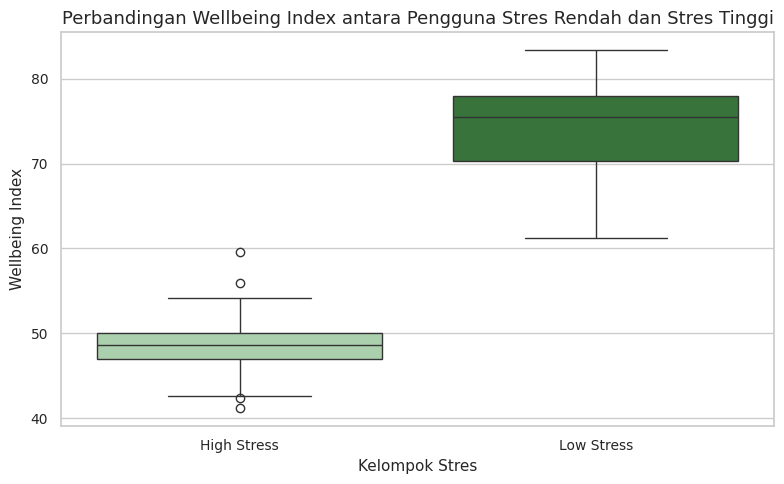

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=ab_df,
    x="stress_category",
    y="wellbeing_index",
    order=["High Stress", "Low Stress"],
    palette=["#A5D6A7", "#2E7D32"]
)

plt.title("Perbandingan Wellbeing Index antara Pengguna Stres Rendah dan Stres Tinggi")
plt.xlabel("Kelompok Stres")
plt.ylabel("Wellbeing Index")
plt.tight_layout()
plt.show()

In [ ]:
# fitness score
fitness_result = run_ab_test(
    data=ab_df,
    metric_column="fitness_score"
)

print("A/B Testing 2 - Fitness Score")
print("=" * 50)

print("Jumlah data Group A - Low Stress:", fitness_result["group_a_count"])
print("Jumlah data Group B - High Stress:", fitness_result["group_b_count"])

print("\nRata-rata fitness_score Group A - Low Stress:", fitness_result["group_a_mean"])
print("Rata-rata fitness_score Group B - High Stress:", fitness_result["group_b_mean"])

print("\nMedian fitness_score Group A - Low Stress:", fitness_result["group_a_median"])
print("Median fitness_score Group B - High Stress:", fitness_result["group_b_median"])

print("\nT-statistic:", fitness_result["t_statistic"])
print("P-value:", fitness_result["p_value"])

alpha = 0.05

if fitness_result["p_value"] < alpha:
    print("\nHasil: Terdapat perbedaan fitness_score yang signifikan antara pengguna dengan stres rendah dan stres tinggi.")
else:
    print("\nHasil: Tidak terdapat perbedaan fitness_score yang signifikan antara pengguna dengan stres rendah dan stres tinggi.")

print("\nCohen's d:", fitness_result["cohens_d"])
print("Interpretasi effect size:", fitness_result["effect_size_interpretation"])

A/B Testing 2 - Fitness Score
Jumlah data Group A - Low Stress: 99
Jumlah data Group B - High Stress: 139

Rata-rata fitness_score Group A - Low Stress: 36.77540571107039
Rata-rata fitness_score Group B - High Stress: 32.77422246505677

Median fitness_score Group A - Low Stress: 34.700567606857255
Median fitness_score Group B - High Stress: 33.18968449153349

T-statistic: 2.582030088304632
P-value: 0.010536163165942922

Hasil: Terdapat perbedaan fitness_score yang signifikan antara pengguna dengan stres rendah dan stres tinggi.

Cohen's d: 0.3443659152731907
Interpretasi effect size: efek kecil


/tmp/ipykernel_3418/4267027030.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


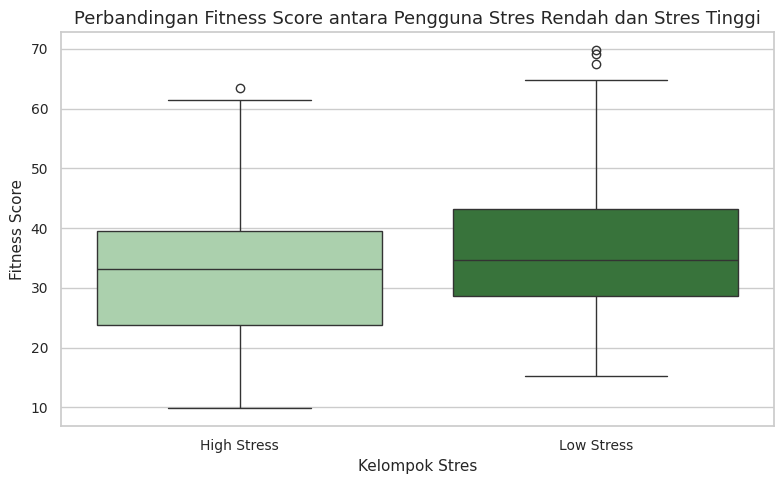

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=ab_df,
    x="stress_category",
    y="fitness_score",
    order=["High Stress", "Low Stress"],
    palette=["#A5D6A7", "#2E7D32"]
)

plt.title("Perbandingan Fitness Score antara Pengguna Stres Rendah dan Stres Tinggi")
plt.xlabel("Kelompok Stres")
plt.ylabel("Fitness Score")
plt.tight_layout()
plt.show()

In [ ]:
# summary
ab_summary = pd.DataFrame([
    {
        "Metric": "wellbeing_index",
        "Group A": "Low Stress",
        "Group B": "High Stress",
        "Mean Group A": wellbeing_result["group_a_mean"],
        "Mean Group B": wellbeing_result["group_b_mean"],
        "Median Group A": wellbeing_result["group_a_median"],
        "Median Group B": wellbeing_result["group_b_median"],
        "T-statistic": wellbeing_result["t_statistic"],
        "P-value": wellbeing_result["p_value"],
        "Cohen's d": wellbeing_result["cohens_d"],
        "Effect Size": wellbeing_result["effect_size_interpretation"]
    },
    {
        "Metric": "fitness_score",
        "Group A": "Low Stress",
        "Group B": "High Stress",
        "Mean Group A": fitness_result["group_a_mean"],
        "Mean Group B": fitness_result["group_b_mean"],
        "Median Group A": fitness_result["group_a_median"],
        "Median Group B": fitness_result["group_b_median"],
        "T-statistic": fitness_result["t_statistic"],
        "P-value": fitness_result["p_value"],
        "Cohen's d": fitness_result["cohens_d"],
        "Effect Size": fitness_result["effect_size_interpretation"]
    }
])

display(ab_summary)

,Metric,Group A,Group B,Mean Group A,Mean Group B,Median Group A,Median Group B,T-statistic,P-value,Cohen's d,Effect Size
0,wellbeing_index,Low Stress,High Stress,73.952534,48.624547,75.539158,48.633743,41.856516,2.135325e-77,6.121042,efek besar
1,fitness_score,Low Stress,High Stress,36.775406,32.774222,34.700568,33.189684,2.582030,1.053616e-02,0.344366,efek kecil


## Interpretasi Hasil A/B Testing

A/B Testing dilakukan dengan membandingkan dua kelompok pengguna berdasarkan tingkat stres, yaitu **Low Stress** sebagai Group A dan **High Stress** sebagai Group B. Dari total 420 baris data, hanya 238 baris yang digunakan dalam pengujian ini karena analisis hanya membandingkan dua kelompok ekstrem, yaitu 99 data pengguna dengan stres rendah dan 139 data pengguna dengan stres tinggi. Data dengan kategori `Moderate Stress` tidak digunakan dalam pengujian agar perbandingan antara dua kelompok menjadi lebih jelas.

### Hipotesis 1: Perbedaan Wellbeing Index berdasarkan Tingkat Stres

Hasil pengujian terhadap `wellbeing_index` menunjukkan perbedaan yang sangat jelas antara kelompok stres rendah dan stres tinggi. Kelompok **Low Stress** memiliki rata-rata `wellbeing_index` sebesar **74,07**, sedangkan kelompok **High Stress** hanya memiliki rata-rata sebesar **48,67**. Selisih rata-ratanya sekitar **25,40 poin**, yang menunjukkan bahwa pengguna dengan tingkat stres rendah memiliki kondisi wellbeing yang jauh lebih baik dibandingkan pengguna dengan tingkat stres tinggi.

Median kedua kelompok juga menunjukkan pola yang sama. Median `wellbeing_index` pada kelompok **Low Stress** adalah **75,73**, sedangkan pada kelompok **High Stress** adalah **48,59**. Karena rata-rata dan median sama-sama menunjukkan perbedaan yang besar, maka hasil ini tidak hanya dipengaruhi oleh beberapa nilai ekstrem, tetapi mencerminkan perbedaan pola yang cukup konsisten antara kedua kelompok.

Hasil Welch’s t-test menghasilkan nilai **t-statistic sebesar 42,71** dan **p-value sebesar 6,15e-80**. Karena p-value jauh lebih kecil dari batas signifikansi 0,05, maka **H0 ditolak**. Artinya, terdapat perbedaan rata-rata `wellbeing_index` yang signifikan secara statistik antara pengguna dengan stres rendah dan pengguna dengan stres tinggi.

Selain itu, nilai **Cohen’s d sebesar 6,21** menunjukkan **effect size yang sangat besar**. Ini berarti perbedaan antara kedua kelompok bukan hanya signifikan secara statistik, tetapi juga sangat kuat secara praktis. Visualisasi boxplot juga memperkuat hasil ini, karena distribusi `wellbeing_index` kelompok **Low Stress** berada jauh di atas kelompok **High Stress** dengan overlap yang sangat kecil.

Dengan demikian, hasil A/B Testing pertama menunjukkan bahwa pengguna dengan tingkat stres rendah cenderung memiliki `wellbeing_index` yang jauh lebih tinggi dibandingkan pengguna dengan tingkat stres tinggi. Temuan ini konsisten dengan hasil EDA sebelumnya, yang menunjukkan bahwa tingkat stres memiliki hubungan negatif yang kuat dengan durasi tidur dan kualitas tidur.

### Hipotesis 2: Perbedaan Fitness Score berdasarkan Tingkat Stres

Hasil pengujian terhadap `fitness_score` juga menunjukkan adanya perbedaan antara kelompok stres rendah dan stres tinggi, tetapi perbedaannya tidak sebesar pada `wellbeing_index`. Kelompok **Low Stress** memiliki rata-rata `fitness_score` sebesar **37,59**, sedangkan kelompok **High Stress** memiliki rata-rata sebesar **33,08**. Selisih rata-ratanya sekitar **4,51 poin**, yang berarti pengguna dengan stres rendah cenderung memiliki skor aktivitas atau kebugaran yang sedikit lebih tinggi dibandingkan pengguna dengan stres tinggi.

Median `fitness_score` juga menunjukkan pola serupa. Kelompok **Low Stress** memiliki median sebesar **36,10**, sedangkan kelompok **High Stress** memiliki median sebesar **33,07**. Perbedaannya tetap terlihat, tetapi tidak terlalu besar. Hal ini juga terlihat pada boxplot, di mana distribusi kedua kelompok masih memiliki area yang cukup tumpang tindih. Artinya, meskipun kelompok stres rendah cenderung memiliki `fitness_score` lebih tinggi, masih ada pengguna dengan stres tinggi yang memiliki aktivitas fisik cukup baik, dan sebaliknya.

Hasil Welch’s t-test menghasilkan nilai **t-statistic sebesar 2,84** dan **p-value sebesar 0,005**. Karena p-value lebih kecil dari 0,05, maka **H0 ditolak**. Artinya, terdapat perbedaan rata-rata `fitness_score` yang signifikan secara statistik antara pengguna dengan stres rendah dan pengguna dengan stres tinggi.

Namun, nilai **Cohen’s d sebesar 0,38** menunjukkan **effect size kecil**. Ini berarti perbedaan `fitness_score` antara kedua kelompok memang signifikan secara statistik, tetapi kekuatan perbedaannya relatif kecil secara praktis. Dengan kata lain, tingkat stres memang berkaitan dengan perbedaan aktivitas fisik, tetapi pengaruhnya tidak sekuat pada `wellbeing_index`.



## Kesimpulan A/B Testing

Secara keseluruhan, hasil A/B Testing menunjukkan bahwa tingkat stres membedakan kondisi pengguna secara cukup jelas, terutama pada aspek wellbeing. Perbedaan `wellbeing_index` antara kelompok stres rendah dan stres tinggi sangat besar, baik secara statistik maupun praktis. Sementara itu, perbedaan `fitness_score` juga signifikan, tetapi efeknya kecil.

Temuan ini menunjukkan bahwa stres lebih kuat berkaitan dengan kondisi wellbeing pengguna dibandingkan dengan aktivitas fisik secara langsung. Hal ini masuk akal karena `wellbeing_index` mencakup aspek kualitas tidur, durasi tidur, stres, dan aktivitas fisik, sedangkan `fitness_score` hanya berfokus pada aktivitas fisik seperti jumlah langkah, menit aktivitas intens, dan kalori terbakar.

Dengan demikian, tingkat stres dapat dianggap sebagai faktor penting dalam analisis kondisi wellbeing pengguna. Namun, karena data ini bukan berasal dari eksperimen acak yang dikontrol secara langsung, hasil A/B Testing ini tidak dapat diartikan sebagai hubungan sebab-akibat mutlak. Interpretasi yang lebih tepat adalah bahwa terdapat perbedaan yang signifikan antara kelompok stres rendah dan stres tinggi pada dataset April 2016, terutama dalam hal wellbeing pengguna.